In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
Nr = 1  #number of receptor by cell
Nd = 25   #number of days

dx = 0.025
dt = 0.0005

XX = np.linspace(0, Nr, int(Nr/dx))

k1 = 0.02 #egf influx rate
k2 = 1e-8 #egf consumption
k3 = 0.005  #egf degradation rate  ~ 4 hours

e0 = 1


k4 = 0.005 # movement to profliferative state following EGF consumption
k5 = 0.000001 # movement to quiescency due to exposure to immune cells
k6 = 0.005 # movement to quiescency

k7 = 1.45   #proliferation rate
k77 = 1      #apoptosis rate

#k8 = 0.000013      # elimination rate by immune cells

k9 = 0.01/1e7       # activation by of immune cells
a0 = 0.0
a1 = 1     

i0 = 1e7      #10^7 cells per mililiter
k10 = 0.00000005      #rate of immunosuppression

b0 = 0
b1 = 1

k11 = 0.2

def integrate_vector(c, dx):
    return np.trapz(c, dx=dx)

def act(a0, a1, dx, XX, c):
    return np.trapz(c*(a0 + a1*XX), dx=dx)




In [3]:
print(1/0.025)

40.0


Simulation

In [4]:
def simulation(k4, k5, k6, k8, k10, k7, ktreat):

    c = np.zeros([int(Nr/dx)])
    c_new = np.zeros([int(Nr/dx)])
    
    e = e0
    e_new = e0
    
    cT = np.zeros([int(Nd)])
    eT = np.zeros([int(Nd)])
    iT = np.zeros([int(Nd)])
    nT = np.zeros([int(Nd)])
    c_p_T = np.zeros([int(Nr/dx), int(Nd)])
    
    i = 0
    i_new = 0
    
    # Initial condition for c
    for ix in range(int(Nr/dx)):
        if int(0.4/dx) <= ix < int(0.6/dx):
            c[ix] = 70000000
    
    cT[0] = np.trapz(c, dx=dx)
    print(cT[0])
    eT[0] = e
    iT[0] = i
    nT[0] = np.trapz(c, dx=dx)*2e-6
    c_p_T[:, 0] = c.copy()
    
    day = 1  # day counter for indexing into cT, eT, iT
    
    for t in range(1, int(Nd/dt)):
        e_new = e + dt*(k1*(e0-e) - k2*integrate_vector(XX*c, dx)*e - k3*e)
        i_new = i + dt*(k9*act(a0, a1, dx, XX, c)*(i0-i) - k10*act(b0, b1, dx, (1-XX), c)*i - k11*i)
    
        for ix in range(1, int(Nr/dx)-1):
            c_new[ix] = (c[ix] 
                         - (dt*k4*e*(Nr - XX[ix])*(c[ix] - c[ix-1])/dx + dt*k4*e*c[ix])
                         
                         + dt*k5*i*XX[ix]*(c[ix+1] - c[ix])/dx + dt*k5*i*c[ix]

                         - (dt*ktreat*(Nr - XX[ix])*(c[ix] - c[ix-1])/dx + dt*ktreat*c[ix])
                         
                         + dt*k6*XX[ix]*(1-e)*(c[ix+1] - c[ix])/dx + dt*k6*(1-e)*c[ix]
                         
                         + dt*k7*XX[ix]*c[ix]
                         - dt*k8*i*XX[ix]*c[ix]
                         - dt*k77*XX[ix]*c[ix])
    
        # Boundary conditions
        #c_new[0] = c[1]
        #c_new[-1] = c[-2]
    
        e = e_new
        i = i_new
        c = c_new.copy()
    
        if t % int(1/dt) == 0:
            eT[day] = e
            cT[day] = np.trapz(c, dx=dx)
            iT[day] = i
            nT[day] = np.trapz(c, dx=dx)*2e-6
            c_p_T[:, day] = c.copy()
            day += 1
            

    return eT, cT, iT, nT, c_p_T

In [5]:
Xdata = [0, 3, 6, 9, 12, 15, 18, 21]
Ydata1 = [20, 40, 100, 220, 320, 520, 780, 1190]
Ydata2 = [20, 40, 80, 120, 180, 270, 320, 440]

In [6]:
k4 = 0.01        # movement to profliferative state following EGF consumption
k5 = 0.1/1e7     # movement to quiescency due to exposure to immune cells
k6 = 0.01        #movement to quiescency due to stress
k8 = 1e-5    # elimination rate by immune cells
k10 = 1e-6      #rate of immunosuppression
k7 = 1.5         #division rate

eT, cT, iT, nT, c_p_T = simulation(k4, k5, k6, k8, k10, k7, 0)

12250000.0


In [7]:
k4 = 0.01 # movement to profliferative state following EGF consumption
k5 = 0.50/1e7 # movement to quiescency due to exposure to immune cells
k6 = 0.01  #movement to quiescency due to stress
k8 = 1e-5      # elimination rate by immune cells
k10 = 1e-6       #rate of immunosuppression
k7 = 1.5          #division rate
 
eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4, k5, k6, k8, k10, k7, 0.03)

12250000.0


In [8]:
k4 = 0.01 # movement to profliferative state following EGF consumption
k5 = 0.1/1e7 # movement to quiescency due to exposure to immune cells
k6 = 0.01  #movement to quiescency due to stress
k8 = 1e-5      # elimination rate by immune cells
k10 = 1e-6       #rate of immunosuppression
k7 = 1.5          #division rate

k777 = np.linspace(1.1, 1.6, 10)
immsup = np.linspace(5e-7, 2e-6, 10)

res_eff_immsup = np.zeros((len(k777), len(immsup)))

for i in range(len(k777)):
    for j in range(len(immsup)):
        eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4, k5, k6, k8, immsup[j], k777[i], 0.03)

        eT1, cT1, iT1, nT1, c_p_T1 = simulation(k4, k5, k6, k8, immsup[j], k777[i], 0.0)
        
        res_eff_immsup[i, j] = (cT1[24] - cT2[24])/cT1[24]  # or nT2[-1] if preferred



12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0

In [9]:
for i in range(len(k777)):
    for j in range(len(immsup)):
        if (res_eff_immsup[i, j] < 0):
            res_eff_immsup[i, j] = 0

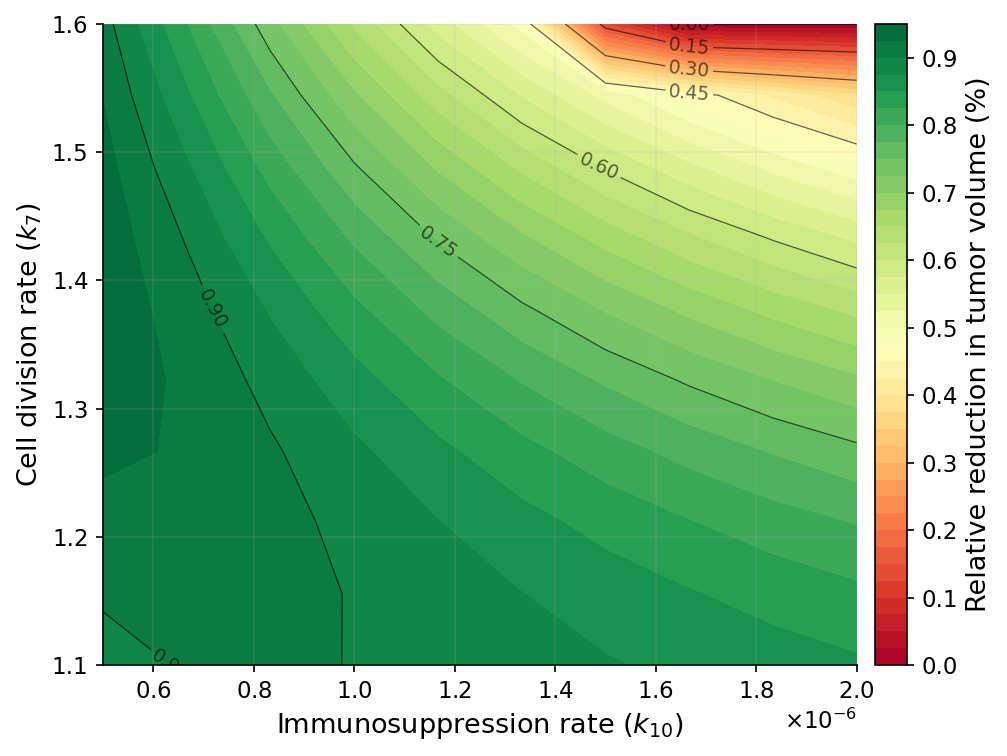

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Meshgrid (important: immsup = x-axis, k777 = y-axis)
X, Y = np.meshgrid(immsup, k777)

# ===============================
# Plot
# ===============================
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

fig, ax = plt.subplots(figsize=(7.0, 5.2))

# Filled contours
cf = ax.contourf(
    X, Y, res_eff_immsup,
    levels=40,
    cmap="RdYlGn"
)

# Add contour lines
cs = ax.contour(
    X, Y, res_eff_immsup,
    levels=8,
    colors="black",
    linewidths=0.6,
    alpha=0.6
)
ax.clabel(cs, inline=True, fontsize=9, fmt="%.2f")

# Colorbar
cbar = plt.colorbar(cf, ax=ax, pad=0.02)
cbar.set_label("Relative reduction in tumor volume (%)", rotation=90)

# Axis labels
ax.set_xlabel("Immunosuppression rate ($k_{10}$)")
ax.set_ylabel("Cell division rate ($k_7$)")

# Scientific notation for x-axis
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Grid (very subtle)
ax.grid(alpha=0.15)

plt.tight_layout()
plt.savefig('fig2.png')
plt.show()


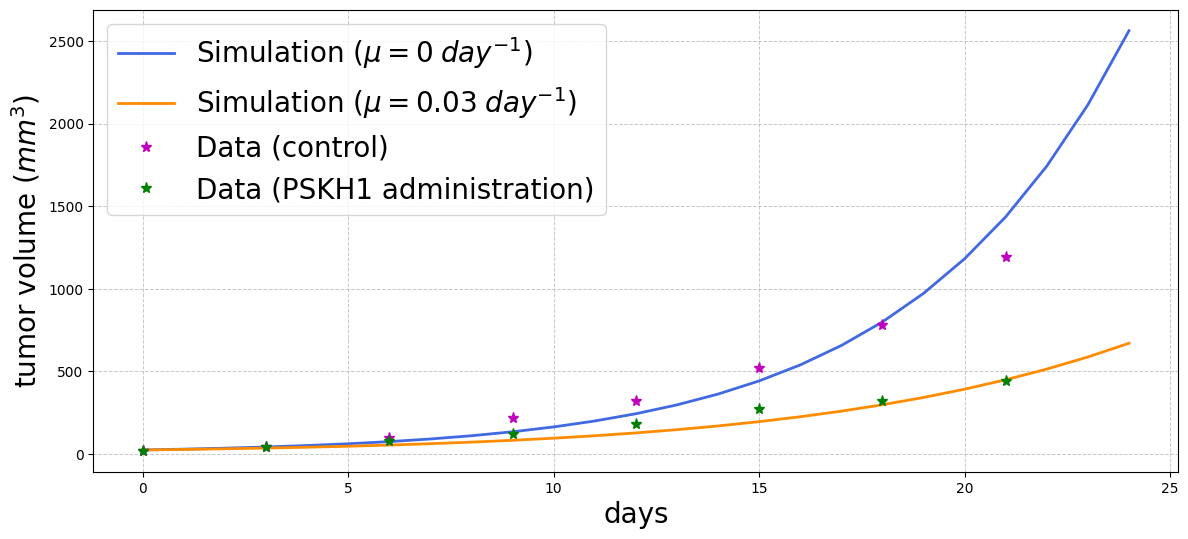

In [10]:
plt.figure(figsize=(14,6))

# Plot the simulated data with contrasting colors
plt.plot(nT, color='royalblue', linestyle='-', linewidth=2, label=r'Simulation ($\mu = 0 \; day^{-1})$')
plt.plot(nT2, color='darkorange', linestyle='-', linewidth=2, label=r'Simulation ($\mu = 0.03 \; day^{-1})$')

# Plot the observed data points
plt.plot(Xdata, Ydata1, 'm*', markersize=8, label='Data (control)')  # magenta stars
plt.plot(Xdata, Ydata2, 'g*', markersize=8, label='Data (PSKH1 administration)')  # green stars

# Add labels and title
plt.xlabel('days', fontsize = 20)
plt.ylabel(r'tumor volume ($mm^3$)', fontsize = 20)

# Turn on grid
plt.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7)

# Show legend
plt.legend(fontsize = 20)
plt.savefig('valid.png')
# Display the plot
plt.show()

In [13]:
import numpy as np

# Experimental data
Xdata = [0, 3, 6, 9, 12, 15, 18, 21]
Ydata1 = [20, 40, 100, 220, 320, 520, 780, 1190]
Ydata2 = [20, 40, 80, 120, 180, 270, 320, 440]

# Example: if your simulation time grid is called T
# T must have the same length as nT and nT2
# Example: T = np.linspace(0, 12, len(nT))

T = np.linspace(0, 25, len(nT))  # adjust if your simulation ends at another time

# Interpolate simulations at experimental time points
sim_control_at_data = np.interp(Xdata, T, nT)
sim_1639_at_data = np.interp(Xdata, T, nT2)

# Mean squared errors
mse_control = np.mean((sim_control_at_data - Ydata1)**2)
mse_1639 = np.mean((sim_1639_at_data - Ydata2)**2)

# Combined MSE
mse_total = np.mean(
    np.concatenate([
        (sim_control_at_data - Ydata1)**2,
        (sim_1639_at_data - Ydata2)**2
    ])
)

print("MSE control:", mse_control)
print("MSE 1639:", mse_1639)
print("Combined MSE:", mse_total)

MSE control: 5358.604280661193
MSE 1639: 2265.992793541404
Combined MSE: 3812.2985371012987


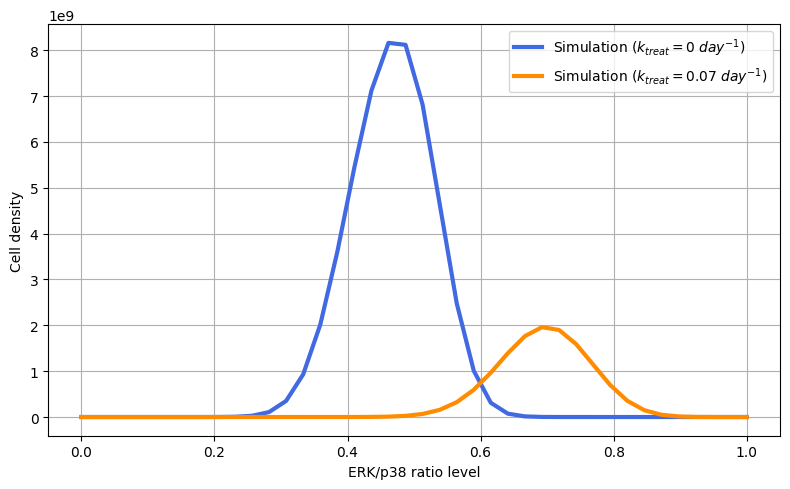

In [170]:
day = 24

plt.figure(figsize=(8, 5))

# Plot with distinct colors and labels
plt.plot(XX, c_p_T[:, day], color='royalblue', label=r'Simulation ($k_{treat} = 0 \; {day}^{-1})$', lw = 3)
plt.plot(XX, c_p_T2[:, day], color='darkorange', label=r'Simulation ($k_{treat} = 0.07 \; {day}^{-1})$', lw = 3)

# Add labels, title, legend, and grid
plt.xlabel('ERK/p38 ratio level')
plt.ylabel('Cell density')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('density.png')
plt.show()

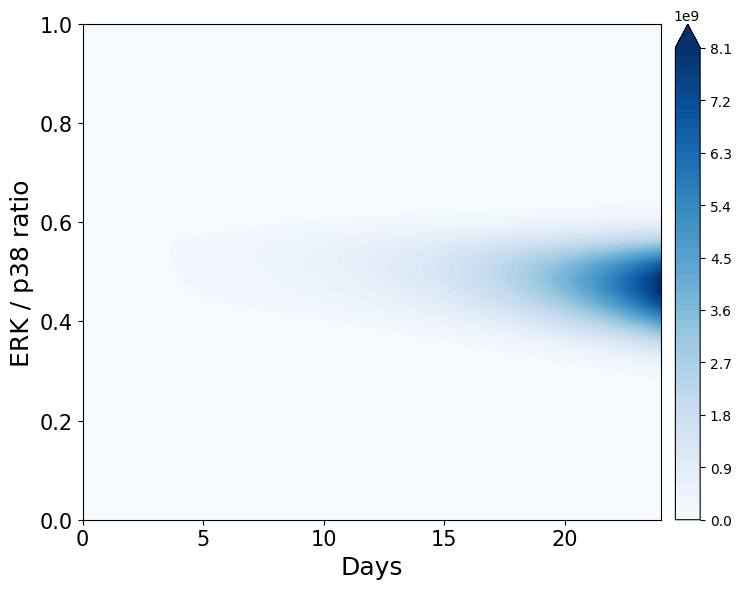

In [25]:
Y = np.linspace(0, 24, 25)
X = np.linspace(0, Nr, int(Nr/dx))


fig, ax = plt.subplots(figsize=(8, 6))

contour = ax.contourf(
    Y, X, c_p_T,
    levels=60,                # smoother gradients
    cmap='Blues',             # better than viridis for intensity
    extend='max'
)

cbar = plt.colorbar(contour, ax=ax, pad=0.02)
#cbar.set_label('Cells', fontsize=12)
cbar.ax.tick_params(labelsize=10)

ax.set_xlabel('Days', fontsize=18)
ax.set_ylabel('ERK / p38 ratio', fontsize=18)

ax.tick_params(axis='both', labelsize=15)
ax.set_aspect('auto')

plt.tight_layout()
plt.savefig('distr2.png')
plt.show()


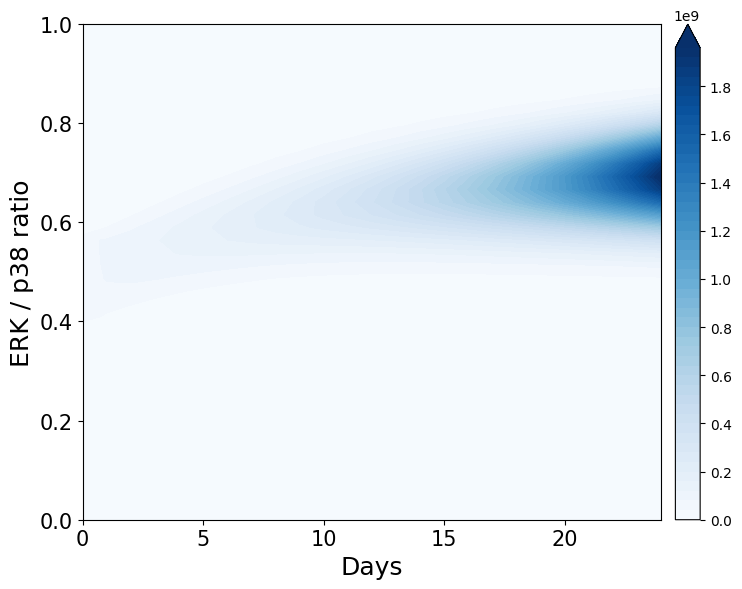

In [24]:



fig, ax = plt.subplots(figsize=(8, 6))

contour = ax.contourf(
    Y, X, c_p_T2,
    levels=60,                # smoother gradients
    cmap='Blues',             # better than viridis for intensity
    extend='max'
)

cbar = plt.colorbar(contour, ax=ax, pad=0.02)
#cbar.set_label('Cells', fontsize=12)
cbar.ax.tick_params(labelsize=10)

ax.set_xlabel('Days', fontsize=18)
ax.set_ylabel('ERK / p38 ratio', fontsize=18)

ax.tick_params(axis='both', labelsize=15)
ax.set_aspect('auto')

plt.tight_layout()
plt.savefig('distr.png')
plt.show()

In [146]:
Xdata = [0, 3, 6, 9, 12, 15, 18, 21]
Ydata1 = [20, 40, 100, 220, 320, 520, 780, 1190]
Ydata2 = [20, 40, 80, 120, 180, 270, 320, 440]

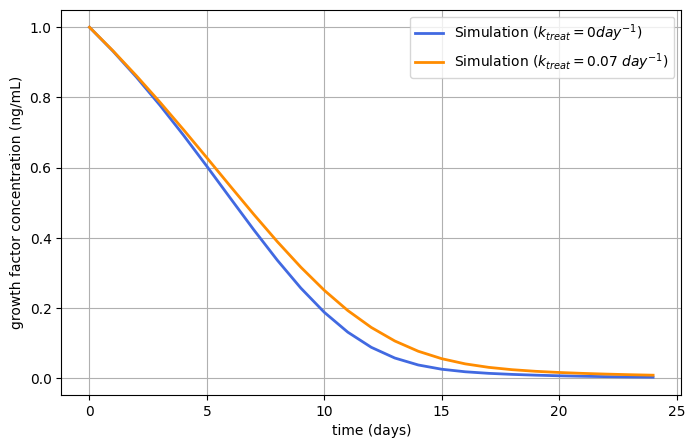

In [173]:
plt.figure(figsize=(8, 5))


plt.plot(eT, color='royalblue', linestyle='-', linewidth=2, label=r'Simulation ($k_{treat} = 0 day^{-1})$')
plt.plot(eT2, color='darkorange', linestyle='-', linewidth=2, label=r'Simulation ($k_{treat} = 0.07 \; day^{-1})$')

plt.xlabel('time (days)')
plt.ylabel('growth factor concentration (ng/mL)')
plt.legend()
plt.grid(True)

plt.savefig('GF.png')
plt.show()

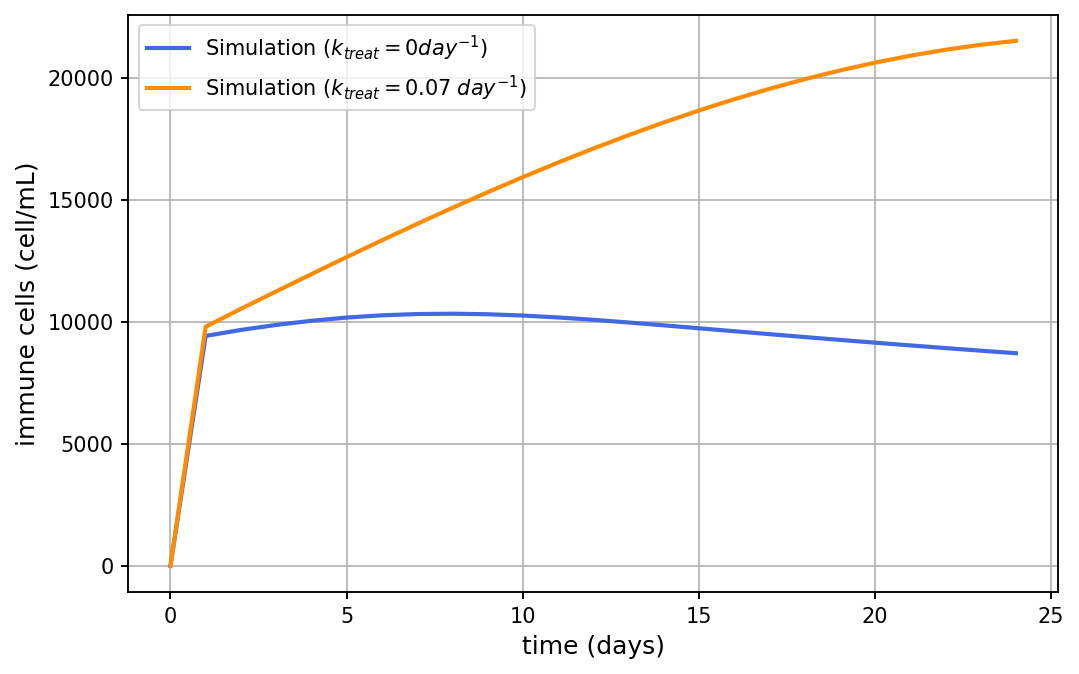

In [227]:
plt.figure(figsize=(8, 5))


plt.plot(iT, color='royalblue', linestyle='-', linewidth=2, label=r'Simulation ($k_{treat} = 0 day^{-1})$')
plt.plot(iT2, color='darkorange', linestyle='-', linewidth=2, label=r'Simulation ($k_{treat} = 0.07 \; day^{-1})$')

plt.xlabel('time (days)')
plt.ylabel('immune cells (cell/mL)')
plt.legend()
plt.grid(True)

plt.savefig('Imm.png')
plt.show()

In [176]:
k4 = 0.01 # movement to profliferative state following EGF consumption
k5 = 0.1/1e7 # movement to quiescency due to exposure to immune cells
k6 = 0.01  #movement to quiescency due to stress
k8 = 1e-5      # elimination rate by immune cells
k10 = 1e-6       #rate of immunosuppression
k7 = 1.5          #division rate

eT, cT, iT2, nT, c_p_T = simulation(k4, k5, k6, k8, k10, k7, 0.00)
eT1, cT1, iT1, nT1, c_p_T1 = simulation(k4, k5, k6, 2*k8, k10, k7, 0.00)       #double elimination
eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4, k5, k6, k8, k10, k7, 0.07)
eT3, cT3, iT3, nT3, c_p_T3 = simulation(k4, k5, k6, 2*k8, k10, k7, 0.07)       #double elimination

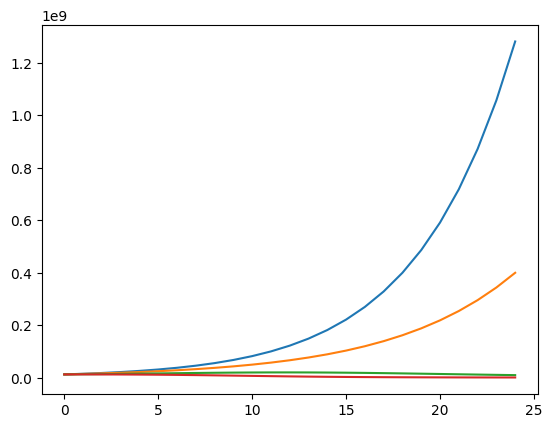

In [177]:
plt.plot(cT)
plt.plot(cT1)
plt.plot(cT2)
plt.plot(cT3)


In [178]:
print((nT[24] - nT2[24])/nT[24])
print((nT1[24] - nT3[24])/nT1[24])      #increased effect when elimination is higher

0.992541350609514
0.9985065318345234


In [582]:
k4 = 0.001 # movement to profliferative state following EGF consumption
k5 = 0.01/1e7 # movement to quiescency due to exposure to immune cells
k6 = 0.01  #movement to quiescency due to stress
k8 = 0.1/1e7      # elimination rate by immune cells
k10 = 1e-2/1e7      #rate of immunosuppression
k7 = 1.465          #division rate
 
eT, cT, iT2, nT, c_p_T = simulation(k4, k5, k6, k8, k10, k7, 0.00)
eT1, cT1, iT1, nT1, c_p_T1 = simulation(k4, k5, k6, k8, 10*k10, k7, 0.00)       #10x times suppression
eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4, k5, k6, k8, k10, k7, 0.07)
eT3, cT3, iT3, nT3, c_p_T3 = simulation(k4, k5, k6, k8, 10*k10, k7, 0.07)       #10x times suppression

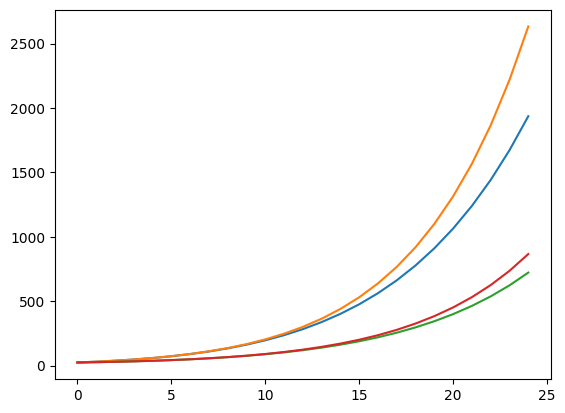

In [583]:
plt.plot(nT)
plt.plot(nT1)
plt.plot(nT2)
plt.plot(nT3)


In [585]:
print((nT[24] - nT2[24])/nT[24])
print((nT1[24] - nT3[24])/nT1[24])      #increased effect when immunosuppression is higher

0.6269630021692699
0.6709519307623787


In [590]:
k4 = 0.001 # movement to profliferative state following EGF consumption
k5 = 0.01/1e7 # movement to quiescency due to exposure to immune cells
k6 = 0.01  #movement to quiescency due to stress
k8 = 0.1/1e7      # elimination rate by immune cells
k10 = 1e-2/1e7      #rate of immunosuppression
k7 = 1.465          #division rate
 
eT, cT, iT2, nT, c_p_T = simulation(k4, k5, k6, k8, k10, k7, 0.00)
eT1, cT1, iT1, nT1, c_p_T1 = simulation(100*k4, k5, k6, k8, k10, k7, 0.00)       #100x times reactivation
eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4, k5, k6, k8, k10, k7, 0.07)
eT3, cT3, iT3, nT3, c_p_T3 = simulation(100*k4, k5, k6, k8, k10, k7, 0.07)       #100x times reactivation

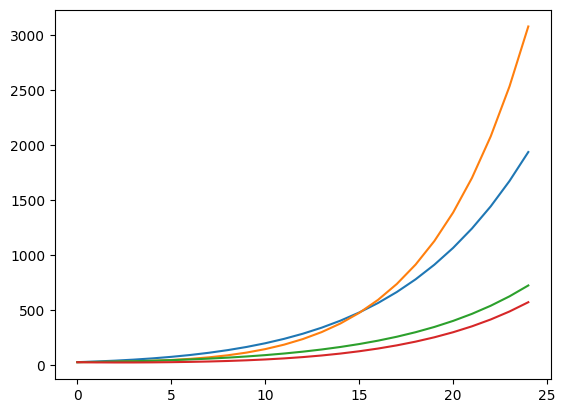

In [591]:
plt.plot(nT)
plt.plot(nT1)
plt.plot(nT2)
plt.plot(nT3)


In [592]:
print((nT[24] - nT2[24])/nT[24])
print((nT1[24] - nT3[24])/nT1[24])      #increased effect when reactivation is higher

0.6269630021692699
0.8148620840101377


In [593]:
k4 = 0.001 # movement to profliferative state following EGF consumption
k5 = 0.01/1e7 # movement to quiescency due to exposure to immune cells
k6 = 0.01  #movement to quiescency due to stress
k8 = 0.1/1e7      # elimination rate by immune cells
k10 = 1e-2/1e7      #rate of immunosuppression
k7 = 1.465          #division rate
 
eT, cT, iT2, nT, c_p_T = simulation(k4, k5, 10*k6, k8, k10, k7, 0.00)
eT1, cT1, iT1, nT1, c_p_T1 = simulation(k4, k5, k6, k8, k10, k7, 0.00)       #10x times dormancy under stress
eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4, k5, 10*k6, k8, k10, k7, 0.07)
eT3, cT3, iT3, nT3, c_p_T3 = simulation(k4, k5, k6, k8, k10, k7, 0.07)       #10x times dormancy under stress

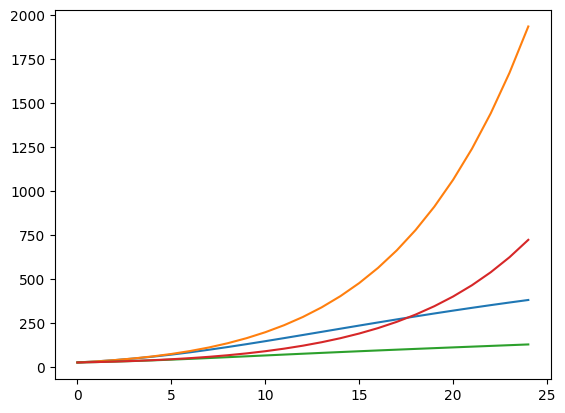

In [594]:
plt.plot(nT)
plt.plot(nT1)
plt.plot(nT2)
plt.plot(nT3)


In [16]:
nT[24]

1936.4546069412097

In [596]:
print((nT[24] - nT2[24])/nT[24])
print((nT1[24] - nT3[24])/nT1[24])      #increased effect when dormancy is higher

0.6655241542900281
0.6269630021692699


In [405]:
import numpy as np
import matplotlib.pyplot as plt




ValueError: setting an array element with a sequence.

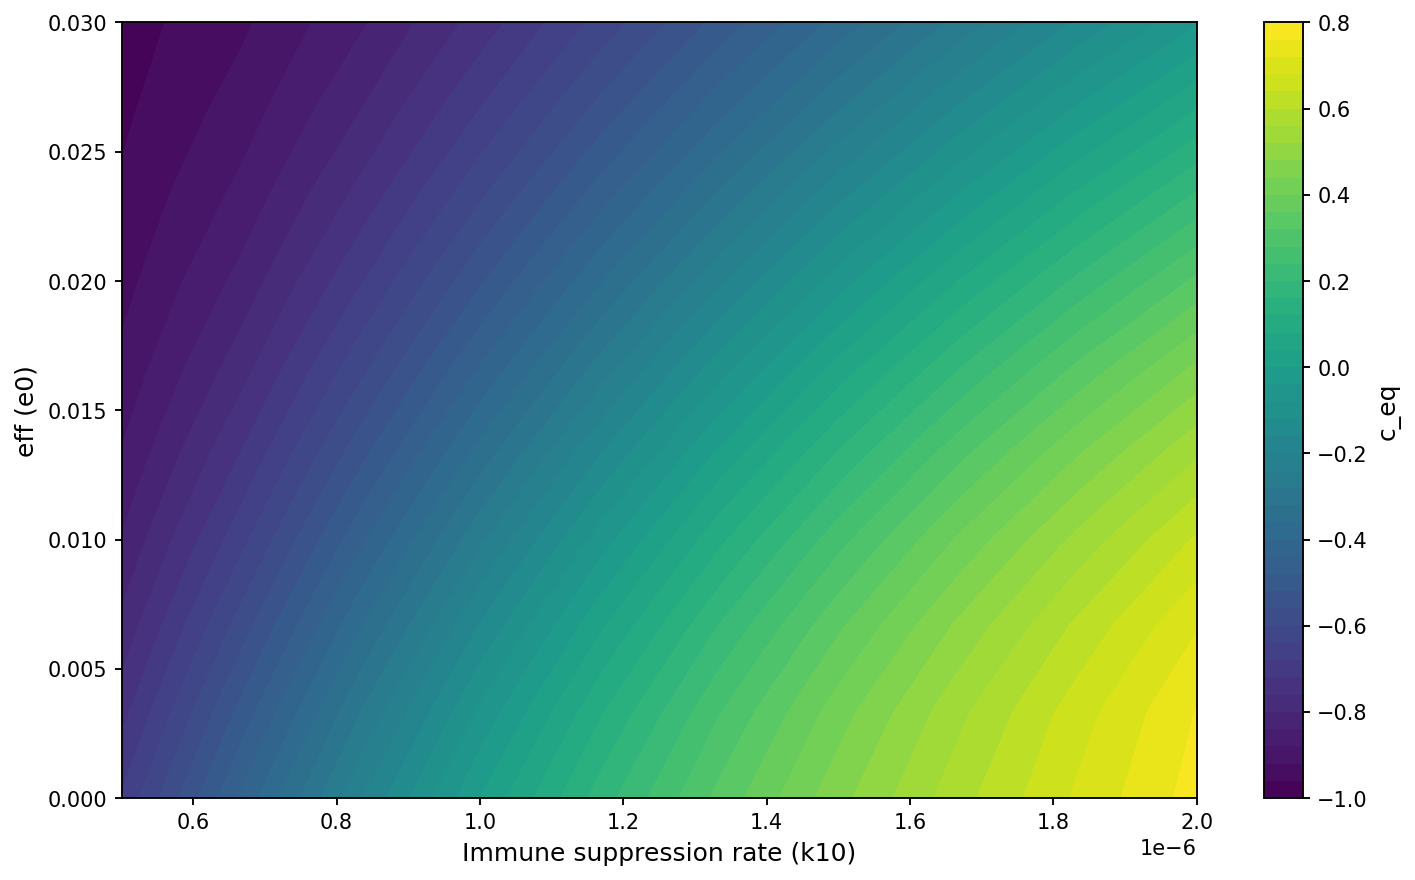

In [207]:
fig, ax = plt.subplots(figsize=(10, 6))
contour = ax.contourf(immsup, eff, res_eff_immsup, levels=50, cmap='viridis')
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('c_eq')

ax.set_xlabel('Immune suppression rate (k10)')
ax.set_ylabel('eff (e0)')

plt.tight_layout()
plt.show()

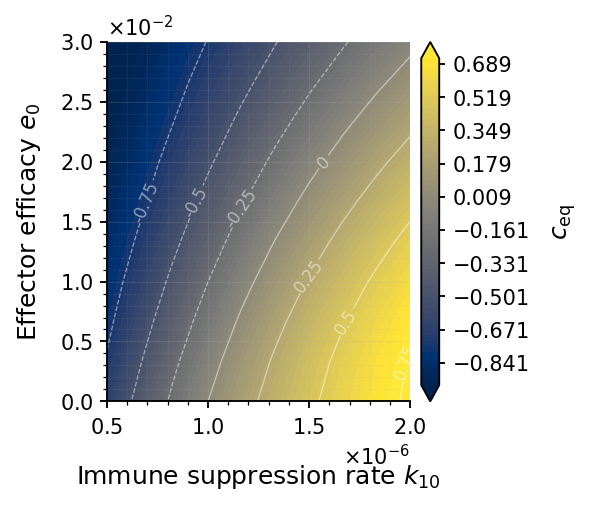

In [208]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, AutoMinorLocator, ScalarFormatter

# =========================================================
# PLOS Computational Biology figure defaults
# =========================================================
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
})

# =========================================================
# Ensure numpy arrays
# =========================================================
immsup = np.asarray(immsup)
eff = np.asarray(eff)
Z = np.asarray((res_eff_immsup))

# Build mesh if immsup and eff are 1D
if immsup.ndim == 1 and eff.ndim == 1:
    X, Y = np.meshgrid(immsup, eff, indexing="xy")
else:
    X, Y = immsup, eff

# =========================================================
# Figure (single-column PLOS width)
# =========================================================
fig, ax = plt.subplots(figsize=(4, 3.5))

# Robust color scaling (avoid outlier domination)
vmin, vmax = np.nanpercentile(Z, [2, 98])
levels = np.linspace(vmin, vmax, 60)

# =========================================================
# Filled contours + contour lines
# =========================================================
cf = ax.contourf(
    X, Y, Z,
    levels=levels,
    cmap="cividis",     # color-blind & grayscale safe
    extend="both"
)

cs = ax.contour(
    X, Y, Z,
    levels=MaxNLocator(8).tick_values(vmin, vmax),
    colors="white",
    linewidths=0.6,
    alpha=0.5
)

ax.clabel(cs, inline=True, fontsize=8, fmt="%.2g")

# =========================================================
# Colorbar
# =========================================================
cbar = fig.colorbar(cf, ax=ax, pad=0.03)
cbar.set_label(r"$c_{\mathrm{eq}}$", labelpad=10)
cbar.ax.tick_params(which="both", direction="out", length=3)

# =========================================================
# Axis labels (extra spacing from ticks)
# =========================================================
ax.set_xlabel(
    r"Immune suppression rate $k_{10}$",
    labelpad=12
)

ax.set_ylabel(
    r"Effector efficacy $e_0$",
    labelpad=8
)

# =========================================================
# Ticks, formatting, grid
# =========================================================
ax.tick_params(axis="both", which="both", direction="out")
ax.tick_params(axis="x", pad=4)
ax.tick_params(axis="y", pad=3)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((-2, 3))
ax.xaxis.set_major_formatter(sf)
ax.yaxis.set_major_formatter(sf)

# Subtle grid (editor-friendly)
ax.grid(True, which="major", linewidth=0.35, alpha=0.25)
ax.grid(True, which="minor", linewidth=0.25, alpha=0.15)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =========================================================
# Layout & export
# =========================================================
fig.tight_layout()

# Vector (preferred by PLOS)
fig.savefig("immsup_eff_contour_plos.pdf", bbox_inches="tight")

# High-resolution raster (if required)
fig.savefig("immsup_eff_contour_plos.tiff", dpi=600, bbox_inches="tight")

plt.show()


In [212]:


k4 = 0.01 # movement to profliferative state following EGF consumption
k5 = 0.1/1e7 # movement to quiescency due to exposure to immune cells
k6 = 0.01  #movement to quiescency due to stress
k8 = 1e-5      # elimination rate by immune cells
k10 = 1e-6       #rate of immunosuppression
k7 = 1.5          #division rate

eff = np.linspace(0, 0.03, 10)

immelim = np.linspace(1e-6, 2e-5, 10)

res_eff_immlim = np.zeros([10, 10])

for i in range(10):
    for j in range(10):
        eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4, k5, k6, immelim[j], k10, k7, eff[i])    
        res_eff_immlim[i,j] = (cT2[24]-cT1[24])/cT1[24]



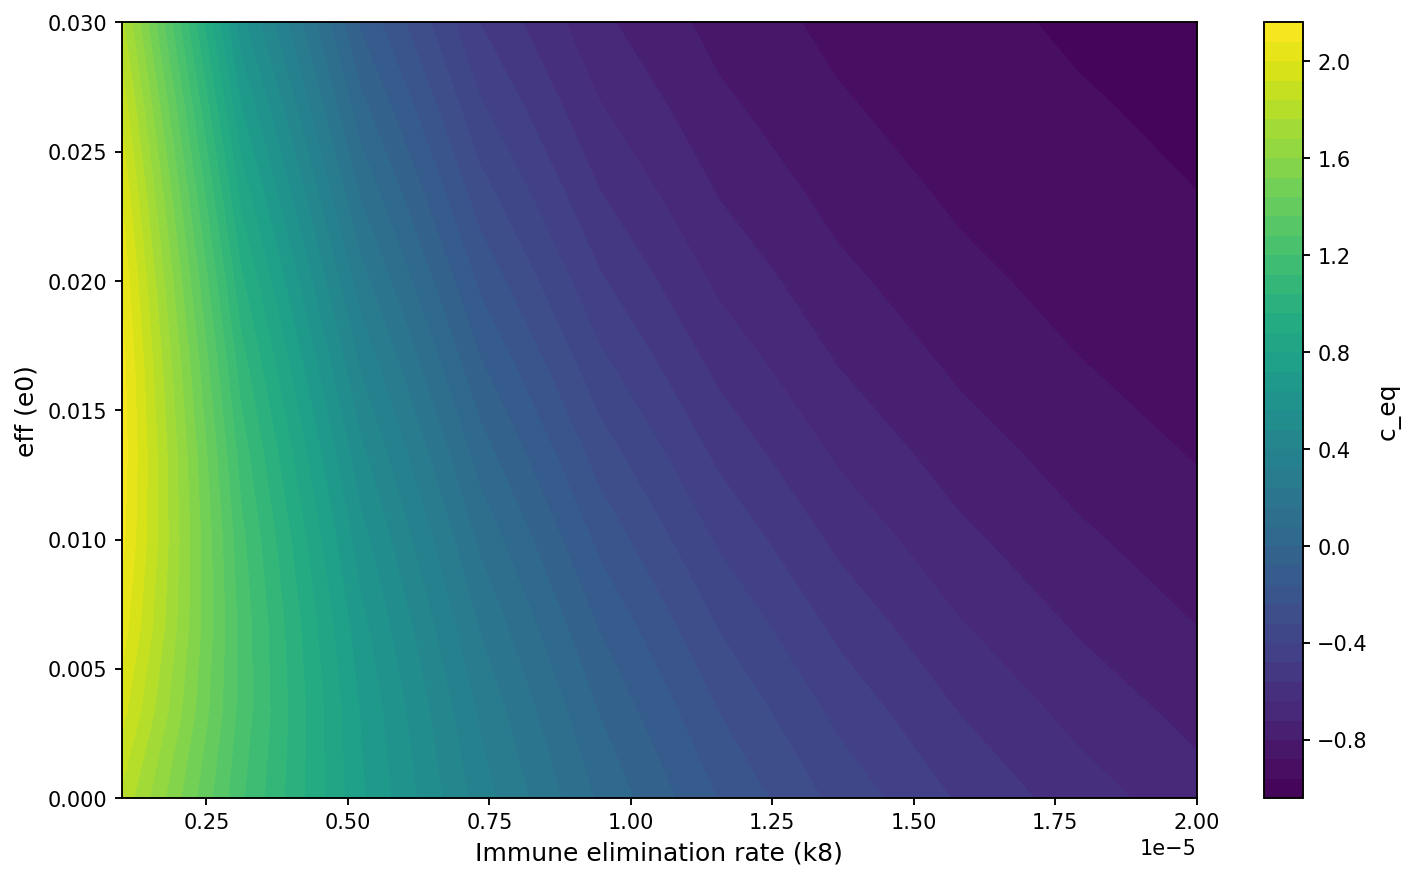

In [213]:




fig, ax = plt.subplots(figsize=(10, 6))
contour = ax.contourf(immelim, eff, res_eff_immlim, levels=50, cmap='viridis')
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('c_eq')

ax.set_xlabel('Immune elimination rate (k8)')
ax.set_ylabel('eff (e0)')

plt.tight_layout()
plt.show()


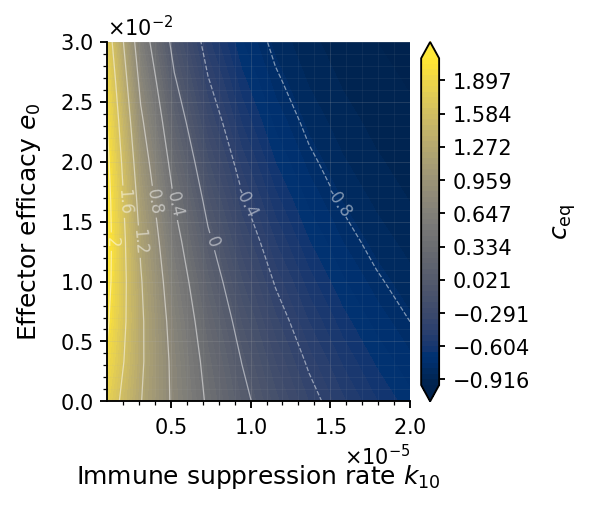

In [214]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, AutoMinorLocator, ScalarFormatter

# =========================================================
# PLOS Computational Biology figure defaults
# =========================================================
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
})

# =========================================================
# Ensure numpy arrays
# =========================================================
immlim = np.asarray(immelim)
eff = np.asarray(eff)
Z = np.asarray((res_eff_immlim))

# Build mesh if immsup and eff are 1D
if immsup.ndim == 1 and eff.ndim == 1:
    X, Y = np.meshgrid(immlim, eff, indexing="xy")
else:
    X, Y = immlim, eff

# =========================================================
# Figure (single-column PLOS width)
# =========================================================
fig, ax = plt.subplots(figsize=(4, 3.5))

# Robust color scaling (avoid outlier domination)
vmin, vmax = np.nanpercentile(Z, [2, 98])
levels = np.linspace(vmin, vmax, 60)

# =========================================================
# Filled contours + contour lines
# =========================================================
cf = ax.contourf(
    X, Y, Z,
    levels=levels,
    cmap="cividis",     # color-blind & grayscale safe
    extend="both"
)

cs = ax.contour(
    X, Y, Z,
    levels=MaxNLocator(8).tick_values(vmin, vmax),
    colors="white",
    linewidths=0.6,
    alpha=0.5
)

ax.clabel(cs, inline=True, fontsize=8, fmt="%.2g")

# =========================================================
# Colorbar
# =========================================================
cbar = fig.colorbar(cf, ax=ax, pad=0.03)
cbar.set_label(r"$c_{\mathrm{eq}}$", labelpad=10)
cbar.ax.tick_params(which="both", direction="out", length=3)

# =========================================================
# Axis labels (extra spacing from ticks)
# =========================================================
ax.set_xlabel(
    r"Immune suppression rate $k_{10}$",
    labelpad=12
)

ax.set_ylabel(
    r"Effector efficacy $e_0$",
    labelpad=8
)

# =========================================================
# Ticks, formatting, grid
# =========================================================
ax.tick_params(axis="both", which="both", direction="out")
ax.tick_params(axis="x", pad=4)
ax.tick_params(axis="y", pad=3)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((-2, 3))
ax.xaxis.set_major_formatter(sf)
ax.yaxis.set_major_formatter(sf)

# Subtle grid (editor-friendly)
ax.grid(True, which="major", linewidth=0.35, alpha=0.25)
ax.grid(True, which="minor", linewidth=0.25, alpha=0.15)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =========================================================
# Layout & export
# =========================================================
fig.tight_layout()

# Vector (preferred by PLOS)
fig.savefig("immsup_eff_contour_plos.pdf", bbox_inches="tight")

# High-resolution raster (if required)
fig.savefig("immsup_eff_contour_plos.tiff", dpi=600, bbox_inches="tight")

plt.show()


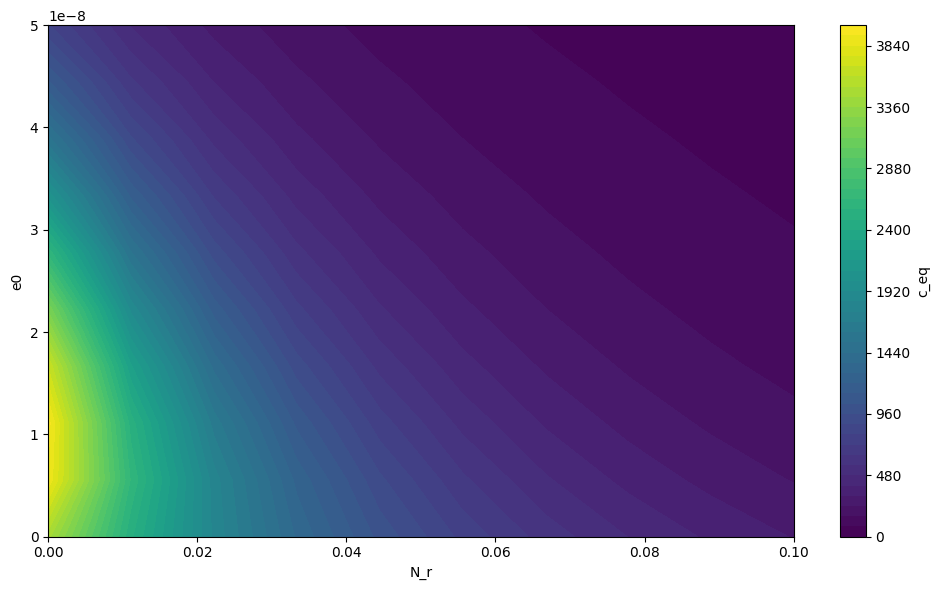

In [43]:


fig, ax = plt.subplots(figsize=(10, 6))
contour = ax.contourf(eff, immelim, res_eff_immlim, levels=50, cmap='viridis')
cbar = plt.colorbar(contour)
cbar.set_label('c_eq')
ax.set_xlabel('N_r')
ax.set_ylabel('e0')
plt.tight_layout()
plt.show()

In [184]:


k4 = 0.001 # movement to profliferative state following EGF consumption
k5 = 0.01/1e7 # movement to quiescency due to exposure to immune cells
k6 = 0.01  #movement to quiescency due to stress
k8 = 0.1/1e7      # elimination rate by immune cells
k10 = 1e-2/1e7      #rate of immunosuppression
k7 = 1.465          #division rate

eff = np.linspace(0, 0.03, 10)

immk7 = np.linspace(1.1, 1.8, 10)

res_eff_immk5 = np.zeros([10, 10])

for i in range(10):
    for j in range(10):
        eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4, k5, k6, k8, k10, immk7[j], eff[i])    
        res_eff_immk5[i,j] = cT2[24]

NameError: name 'immk5' is not defined

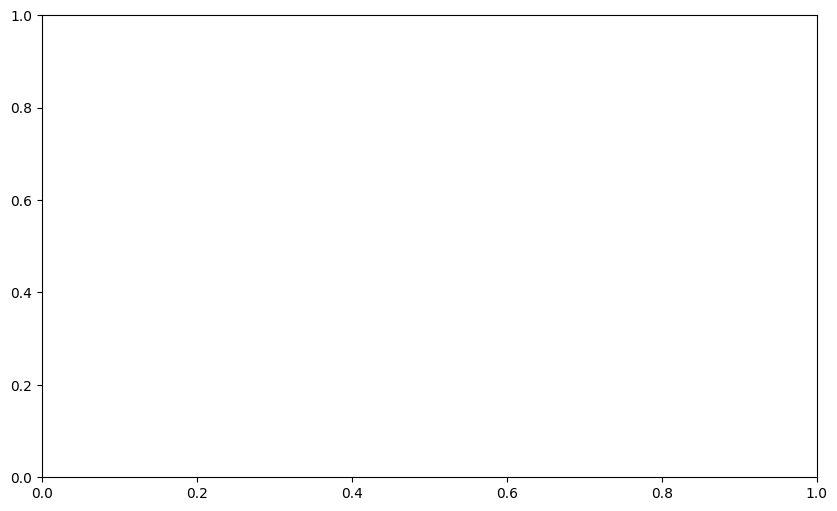

In [185]:


fig, ax = plt.subplots(figsize=(10, 6))
contour = ax.contourf(eff, immk5, res_eff_immk5, levels=50, cmap='viridis')
cbar = plt.colorbar(contour)
cbar.set_label('c_eq')
ax.set_xlabel('N_r')
ax.set_ylabel('e0')
plt.tight_layout()
plt.show()

In [71]:

k4 = 0.001 # movement to profliferative state following EGF consumption
k5 = 0.01/1e7 # movement to quiescency due to exposure to immune cells
k6 = 0.01  #movement to quiescency due to stress
k8 = 0.1/1e7      # elimination rate by immune cells
k10 = 1e-2/1e7      #rate of immunosuppression
k7 = 1.465          #division rate

eT0, cT0, iT0, nT0, c_p_T0 = simulation(k4, k5, k6, k8, 0, k7, 0.1)  
eT1, cT1, iT1, nT1, c_p_T1 = simulation(k4, k5, k6, k8, 1e-7, k7, 0.1)  
eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4, k5, k6, k8, 5e-7, k7, 0.1)  

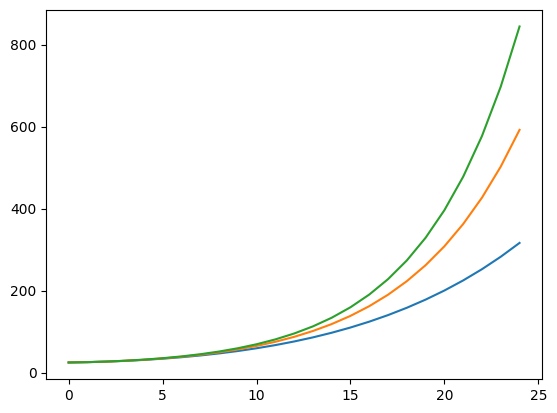

In [72]:
plt.plot(nT0)
plt.plot(nT1)
plt.plot(nT2)

In [67]:

k4 = 0.001 # movement to profliferative state following EGF consumption
k5 = 0.01/1e7 # movement to quiescency due to exposure to immune cells
k6 = 0.01  #movement to quiescency due to stress
k8 = 0.1/1e7      # elimination rate by immune cells
k10 = 1e-2/1e7      #rate of immunosuppression
k7 = 1.465          #division rate

eT0, cT0, iT0, nT0, c_p_T0 = simulation(k4, k5, k6, k8, 0, k7, 0.0)  
eT1, cT1, iT1, nT1, c_p_T1 = simulation(k4, k5, k6, k8, 1e-7, k7, 0.0)  
eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4, k5, k6, k8, 5e-7, k7, 0.0)  

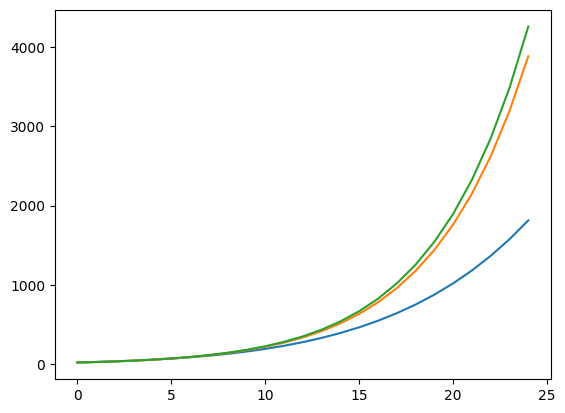

In [69]:
plt.plot(nT0)
plt.plot(nT1)
plt.plot(nT2)

In [116]:

k4 = 0.001 # movement to profliferative state following EGF consumption
k5 = 0.01/1e7 # movement to quiescency due to exposure to immune cells
k6 = 0.01  #movement to quiescency due to stress
k8 = 0.1/1e7      # elimination rate by immune cells
k10 = 1e-2/1e7      #rate of immunosuppression
k7 = 1.465          #division rate

immelim = np.linspace(0, 1/1e7, 10)

immk7 = np.linspace(1, 1.6, 10)

res_k7_immk5_1 = np.zeros([10, 10])

for i in range(10):
    for j in range(10):
        eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4, k5, k6, immelim[j], k10, immk7[i], 0)    
        res_k7_immk5_1[i,j] = nT2[24]

In [223]:

k4 = 0.01 # movement to profliferative state following EGF consumption
k5 = 0.1/1e7 # movement to quiescency due to exposure to immune cells
k6 = 0.01  #movement to quiescency due to stress
k8 = 1e-5      # elimination rate by immune cells
k10 = 1e-6       #rate of immunosuppression
k7 = 1.5          #division rate
eff = np.linspace(0, 0.03, 10)

immk7 = np.linspace(1, 1.8, 10)

res_k7_immk5_2 = np.zeros([10, 10])

for i in range(10):
    for j in range(10):
        eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4, k5, k6, k8, k10, immk7[i], eff[j])    
        res_k7_immk5_2[i,j] = cT2[24]

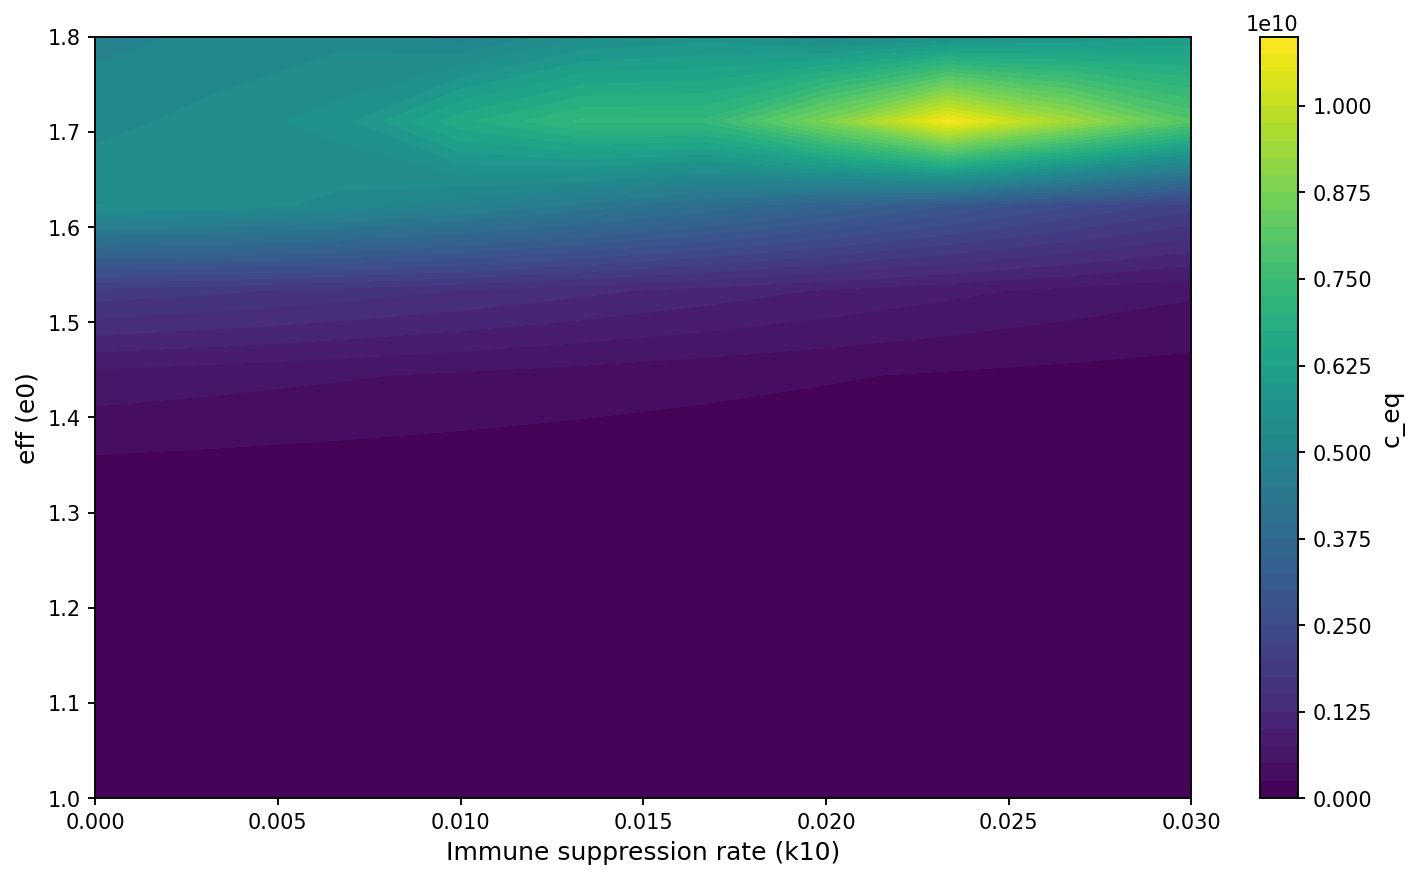

In [224]:
fig, ax = plt.subplots(figsize=(10, 6))
contour = ax.contourf(eff, immk7, res_k7_immk5_2, levels=50, cmap='viridis')
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('c_eq')

ax.set_xlabel('Immune suppression rate (k10)')
ax.set_ylabel('eff (e0)')

plt.tight_layout()
plt.show()

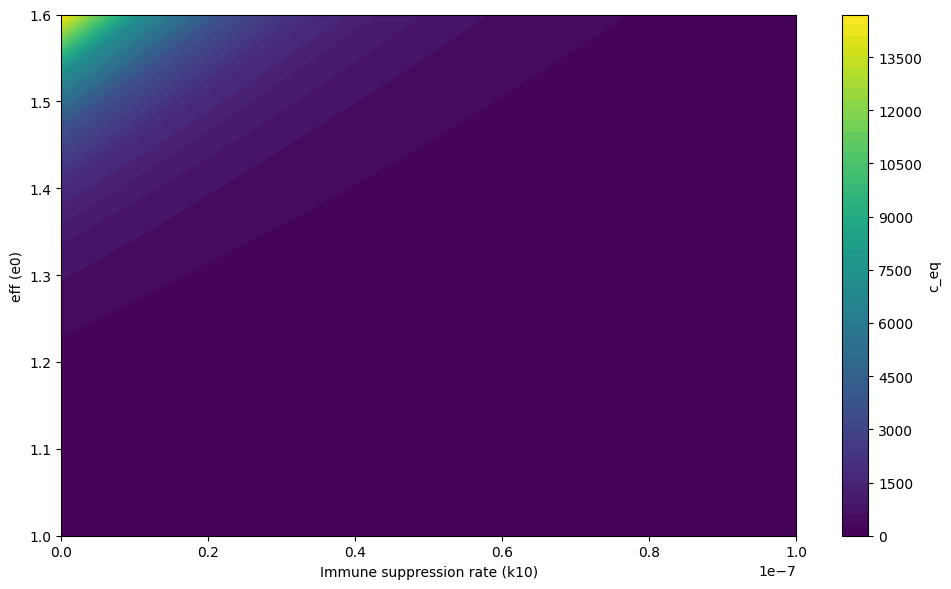

In [119]:
fig, ax = plt.subplots(figsize=(10, 6))
contour = ax.contourf(immelim, immk7, res_k7_immk5_1, levels=50, cmap='viridis')
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('c_eq')

ax.set_xlabel('Immune suppression rate (k10)')
ax.set_ylabel('eff (e0)')

plt.tight_layout()
plt.show()

In [17]:
k4 = 0.01 # movement to profliferative state following EGF consumption
k5 = 0.1/1e7 # movement to quiescency due to exposure to immune cells
k6 = 0.01  #movement to quiescency due to stress
k8 = 1e-5      # elimination rate by immune cells
k10 = 1e-6       #rate of immunosuppression
k7 = 1.5          #division rate

#baseline reduction
eT1, cT1, iT1, nT1, c_p_T1 = simulation(k4, k5, k6, k8, k10, k7, 0)
eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4, k5, k6, k8, k10, k7, 0.03)
baseline_red = (cT1[24] - cT2[24])/cT1[24]

#k4 - reduction
eT1, cT1, iT1, nT1, c_p_T1 = simulation(k4 + 0.2*k4, k5, k6, k8, k10, k7, 0)
eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4 + 0.2*k4, k5, k6, k8, k10, k7, 0.03)
k4_red = (cT1[24] - cT2[24])/cT1[24]

#k5 - reduction
eT1, cT1, iT1, nT1, c_p_T1 = simulation(k4, k5 + 0.2*k5, k6, k8, k10, k7, 0)
eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4, k5 + 0.2*k5, k6, k8, k10, k7, 0.03)
k5_red = (cT1[24] - cT2[24])/cT1[24]

#k6 - redcution
eT1, cT1, iT1, nT1, c_p_T1 = simulation(k4, k5, k6 + 0.2*k6, k8, k10, k7, 0)
eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4, k5, k6 + 0.2*k6, k8, k10, k7, 0.03)
k6_red = (cT1[24] - cT2[24])/cT1[24]

#k8 - redcution
eT1, cT1, iT1, nT1, c_p_T1 = simulation(k4, k5, k6, k8 + 0.2*k8, k10, k7, 0)
eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4, k5, k6, k8 + 0.2*k8, k10, k7, 0.03)
k8_red = (cT1[24] - cT2[24])/cT1[24]

#k10 - redcution
eT1, cT1, iT1, nT1, c_p_T1 = simulation(k4, k5, k6, k8, k10 - 0.2*k10, k7, 0)
eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4, k5, k6, k8, k10 - 0.2*k10, k7, 0.03)
k10_red = (cT1[24] - cT2[24])/cT1[24]

#k7 - redcution
eT1, cT1, iT1, nT1, c_p_T1 = simulation(k4, k5, k6, k8, k10, k7 - 0.2*k7, 0)
eT2, cT2, iT2, nT2, c_p_T2 = simulation(k4, k5, k6, k8, k10, k7 - 0.2*k7, 0.03)
k7_red = (cT1[24] - cT2[24])/cT1[24]


12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0
12250000.0


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Data
# =========================================================
labels = [
    "Baseline",
    r"$k_4$",
    r"$k_5$",
    r"$k_6$",
    r"$k_8$",
    r"$k_{10}$",
    r"$k_7$"
]

values = np.array([
    baseline_red,
    k4_red,
    k5_red,
    k6_red,
    k8_red,
    k10_red,
    k7_red
])

# =========================================================
# PLOS-style defaults
# =========================================================
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.9,
})

# =========================================================
# Figure (single-column width)
# =========================================================
fig, ax = plt.subplots(figsize=(3.4, 2.8))

x = np.arange(len(labels))

bars = ax.bar(
    x,
    values,
    width=0.7,
    edgecolor="black",
    linewidth=0.8
)

# Color emphasis: baseline vs parameters
bars[0].set_color("#8da0cb")     # muted blue for baseline
for b in bars[1:]:
    b.set_color("#fc8d62")       # muted orange for perturbations

# =========================================================
# Labels & formatting
# =========================================================
ax.set_ylabel("Relative reduction in tumor burden", labelpad=8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)

ax.set_ylim(0, 1.05 * np.max(values))

# Subtle grid
ax.grid(axis="y", linewidth=0.4, alpha=0.3)
ax.set_axisbelow(True)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Optional value annotations (comment out if not needed)
for xi, val in zip(x, values):
    ax.text(
        xi, val,
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# =========================================================
# Layout & export
# =========================================================
fig.tight_layout()

fig.savefig("parameter_reduction_comparison.pdf", bbox_inches="tight")
fig.savefig("parameter_reduction_comparison.tiff", dpi=600, bbox_inches="tight")

plt.show()


NameError: name 'baseline_red' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Data
# =========================================================
labels = [
    "Baseline",
    r"$k_4$ (+20\%)",
    r"$k_5$ (+20\%)",
    r"$k_6$ (+20\%)",
    r"$k_8$ (+20\%)",
    r"$k_{10}$ (+20\%)",
    r"$k_7$ (+20\%)"
]

values = np.array([
    baseline_red,
    k4_red,
    k5_red,
    k6_red,
    k8_red,
    k10_red,
    k7_red
])

# =========================================================
# PLOS-style defaults
# =========================================================
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.0,
})

# =========================================================
# Figure (larger size)
# =========================================================
fig, ax = plt.subplots(figsize=(6.8, 4.2))  # ~double-column

x = np.arange(len(labels))

bars = ax.bar(
    x,
    values,
    width=0.7,
    edgecolor="black",
    linewidth=0.9
)

# Color scheme (color-blind safe)
bars[0].set_color("#8da0cb")   # baseline
for b in bars[1:]:
    b.set_color("#fc8d62")     # +20% perturbations

# =========================================================
# Labels & formatting
# =========================================================
ax.set_ylabel("Relative reduction in tumor burden", labelpad=10)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylim(0, 1.1 * np.max(values))

# Grid
ax.grid(axis="y", linewidth=0.4, alpha=0.3)
ax.set_axisbelow(True)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Value annotations
for xi, val in zip(x, values):
    ax.text(
        xi, val,
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# =========================================================
# Layout & export
# =========================================================
fig.tight_layout()

fig.savefig("parameter_reduction_comparison_large.pdf", bbox_inches="tight")
fig.savefig("parameter_reduction_comparison_large.tiff", dpi=600, bbox_inches="tight")

plt.show()


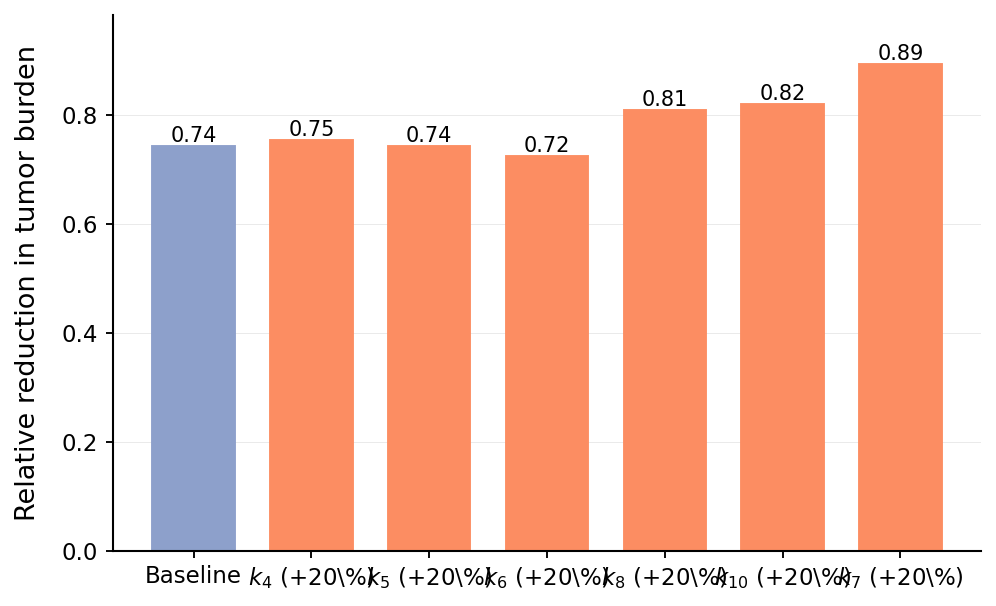

In [229]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Data
"""
k4 = 0.01 # movement to profliferative state following EGF consumption
k5 = 0.1/1e7 # movement to quiescency due to exposure to immune cells
k6 = 0.01  #movement to quiescency due to stress
k8 = 1e-5      # elimination rate by immune cells
k10 = 1e-6       #rate of immunosuppression
k7 = 1.5          #division rate
"""
# =========================================================
labels = [
    "Baseline",
    r"$k_4$ (+20\%)",
    r"$k_5$ (+20\%)",
    r"$k_6$ (+20\%)",
    r"$k_8$ (+20\%)",
    r"$k_{10}$ (+20\%)",
    r"$k_7$ (+20\%)"
]

values = np.array([
    baseline_red,
    k4_red,
    k5_red,
    k6_red,
    k8_red,
    k10_red,
    k7_red
])

# =========================================================
# PLOS-style defaults
# =========================================================
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.0,
})

# =========================================================
# Figure (larger size)
# =========================================================
fig, ax = plt.subplots(figsize=(6.8, 4.2))  # ~double-column

x = np.arange(len(labels))

bars = ax.bar(
    x,
    values,
    width=0.7,
    edgecolor="black",
    linewidth=0.9
)

# Color scheme (color-blind safe)
bars[0].set_color("#8da0cb")   # baseline
for b in bars[1:]:
    b.set_color("#fc8d62")     # +20% perturbations

# =========================================================
# Labels & formatting
# =========================================================
ax.set_ylabel("Relative reduction in tumor burden", labelpad=10)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylim(0, 1.1 * np.max(values))

# Grid
ax.grid(axis="y", linewidth=0.4, alpha=0.3)
ax.set_axisbelow(True)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Value annotations
for xi, val in zip(x, values):
    ax.text(
        xi, val,
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# =========================================================
# Layout & export
# =========================================================
fig.tight_layout()

fig.savefig("parameter_reduction_comparison_large.pdf", bbox_inches="tight")
fig.savefig("parameter_reduction_comparison_large.tiff", dpi=600, bbox_inches="tight")

plt.show()


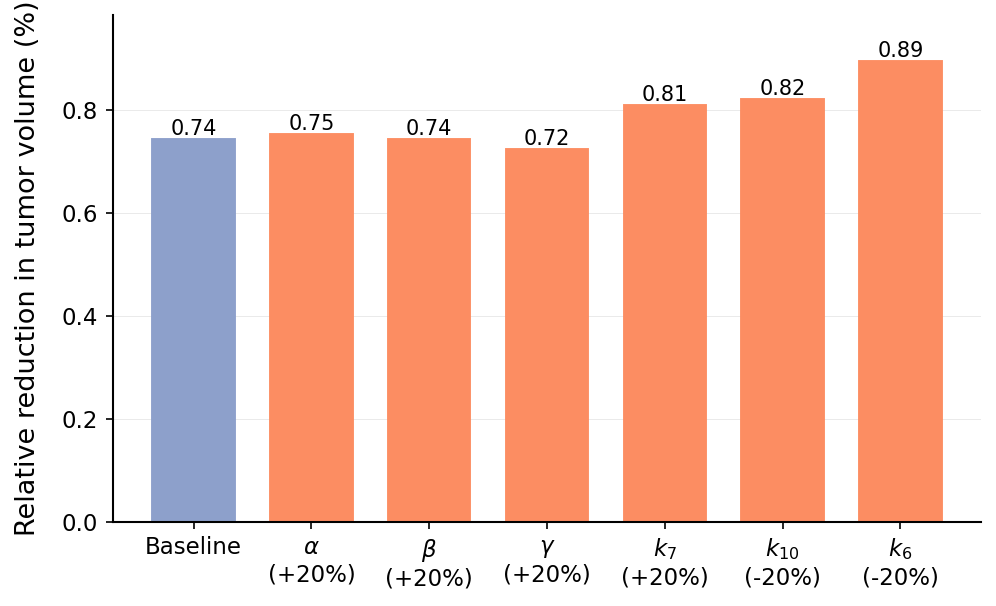

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Parameter mapping (for clarity)
# α = k4, β = k5, γ = k6
# =========================================================

# =========================================================
# Data (ORDER MUST MATCH LABELS)
# =========================================================
labels = [
    "Baseline",
    r"$\alpha$" + "\n(+20%)",
    r"$\beta$"  + "\n(+20%)",
    r"$\gamma$" + "\n(+20%)",
    r"$k_7$"    + "\n(+20%)",
    r"$k_{10}$" + "\n(-20%)",
    r"$k_6$"    + "\n(-20%)"
]

values = np.array([
    baseline_red,
    k4_red,
    k5_red,
    k6_red,
    k8_red,
    k10_red,
    k7_red
])


# =========================================================
# PLOS-style defaults
# =========================================================
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.0,
})

# =========================================================
# Figure (double-column friendly)
# =========================================================
fig, ax = plt.subplots(figsize=(6.8, 4.2))

x = np.arange(len(labels))

bars = ax.bar(
    x,
    values,
    width=0.7,
    edgecolor="black",
    linewidth=0.9
)

# Color scheme
bars[0].set_color("#8da0cb")   # baseline
for b in bars[1:]:
    b.set_color("#fc8d62")

# =========================================================
# Labels & formatting
# =========================================================
ax.set_ylabel("Relative reduction in tumor volume (%)", labelpad=10)

ax.set_xticks(x)
ax.set_xticklabels(labels, linespacing=1.25)

ax.set_ylim(0, 1.1 * np.max(values))

# Grid
ax.grid(axis="y", linewidth=0.4, alpha=0.3)
ax.set_axisbelow(True)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Value annotations
for xi, val in zip(x, values):
    ax.text(
        xi, val,
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# =========================================================
# Layout & export
# =========================================================
fig.tight_layout()

#fig.savefig("parameter_reduction_comparison_large.pdf", bbox_inches="tight")
#fig.savefig("parameter_reduction_comparison_large.tiff", dpi=600, bbox_inches="tight")

plt.show()


In [19]:
import numpy as np

def x_threshold(k10, k7, k6, k9, k8=0.0, clip01=True):
    """
    Compute the threshold x* such that x > x*.

    x* = k10*(k7 - k8) / (k6*k9 + k10*(k7 - k8))

    Parameters
    ----------
    k10, k7, k6, k9 : float or array-like
        Model parameters (can be scalars or numpy arrays).
    k8 : float, optional
        Reference rate in (k7 - k8). Default = 0.
    clip01 : bool, optional
        If True, clip output to [0, 1].

    Returns
    -------
    x_star : float or ndarray
        Threshold value(s).
    """

    k10 = np.asarray(k10, dtype=float)
    k7  = np.asarray(k7, dtype=float)
    k6  = np.asarray(k6, dtype=float)
    k9  = np.asarray(k9, dtype=float)

    numerator = k10 * (k7 - 1)
    denominator = k8 * k9 + numerator

    x_star = np.divide(
        numerator,
        denominator,
        out=np.full_like(denominator, np.nan),
        where=(denominator != 0)
    )

    if clip01:
        x_star = np.clip(x_star, 0.0, 1.0)

    return x_star


In [20]:
k4 = 0.01 # movement to profliferative state following EGF consumption
k5 = 0.1/1e7 # movement to quiescency due to exposure to immune cells
k6 = 0.01  #movement to quiescency due to stress
k8 = 1e-5      # elimination rate by immune cells
k10 = 1e-6       #rate of immunosuppression
k7 = 1.5          #division rate


x_star = x_threshold(k10=1e-6, k7=1.5, k6=0.01, k9=0.01, k8=1e-5)
print(x_star)

0.8333333333333334


In [21]:
num = k10*(1.5-1)
den = k8*(0.01) + num
print(num/den)

0.8333333333333334


In [22]:
k7_v = np.linspace(1.1, 2, 100)
k7_tres = np.zeros(100)

for i in range(100):
    k7_tres[i] = x_threshold(k10=1e-6, k7 = k7_v[i], k6=0.01, k9=0.01, k8=1e-5)

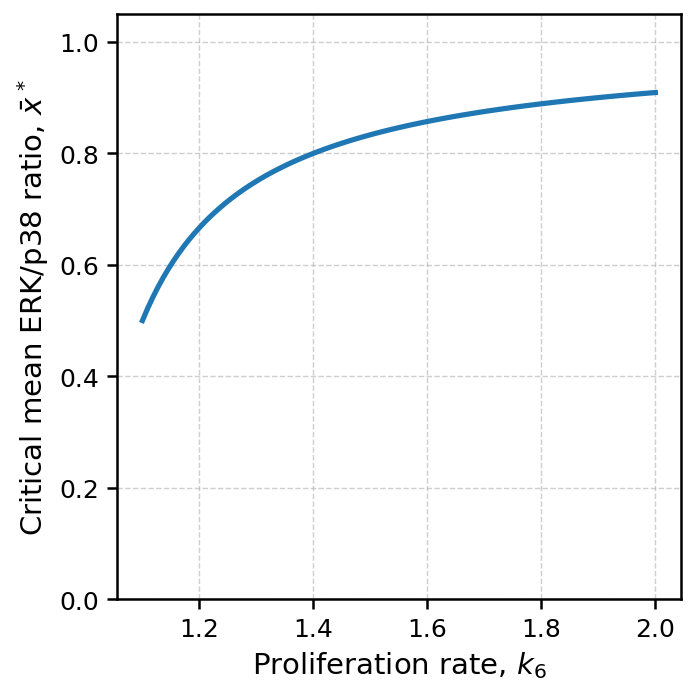

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to arrays if needed
k7_v = np.asarray(k7_v)
k7_tres = np.asarray(k7_tres)

fig, ax = plt.subplots(figsize=(4.8, 4.8))

ax.plot(
    k7_v,
    k7_tres,
    linewidth=2.5
)

ax.set_xlabel(r'Proliferation rate, $k_6$', fontsize=14)
ax.set_ylabel(r'Critical mean ERK/p38 ratio, $\bar{x}^{\,*}$', fontsize=14)

ax.set_ylim(0, 1.05)

ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.6)

ax.tick_params(axis='both', which='major', labelsize=12, width=1.2, length=5)

for spine in ax.spines.values():
    spine.set_linewidth(1.2)

fig.tight_layout()

plt.savefig('x_k6_publication.png', dpi=600, bbox_inches='tight')
plt.savefig('x_k6_publication.pdf', bbox_inches='tight')

plt.show()

In [30]:
k10_v = np.linspace(0, 2e-6, 100)
k10_tres = np.zeros(100)

for i in range(100):
    k10_tres[i] = x_threshold(k10=k10_v[i], k7 = 1.5, k6=0.01, k9=0.01, k8=1e-5)

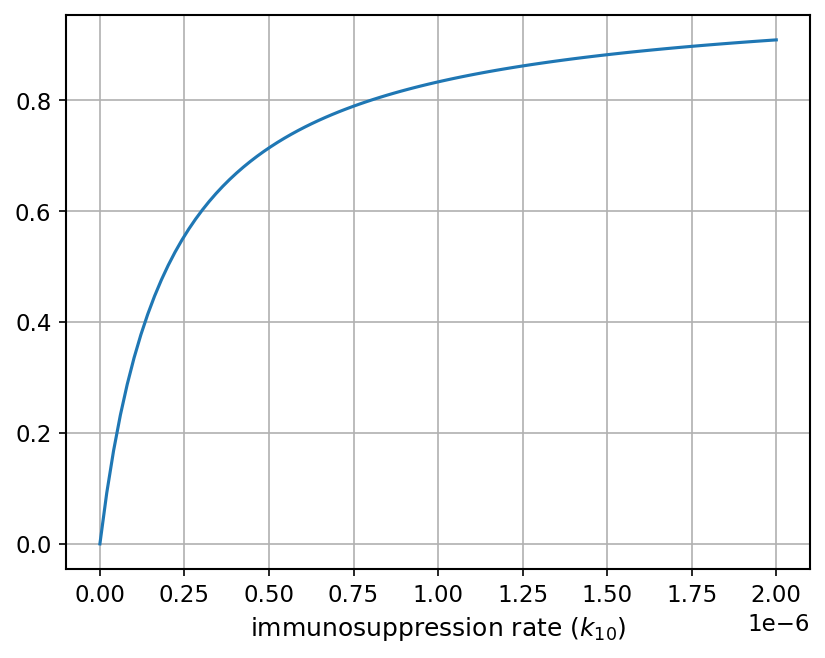

In [31]:
plt.plot(k10_v, k10_tres)
plt.grid()
#plt.ylabel(r'ERK/p38 analytical elimination threshold', fontsize = 12)
plt.xlabel(r'immunosuppression rate ($k_{10}$)', fontsize = 12)
plt.savefig('x_k10.png')
plt.show()

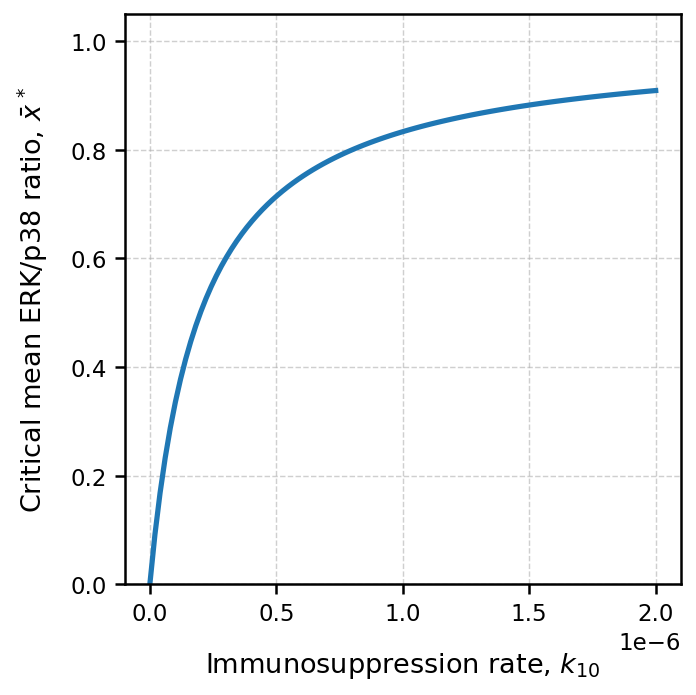

In [39]:
import matplotlib.pyplot as plt
import numpy as np

k10_v = np.asarray(k10_v)
k10_tres = np.asarray(k10_tres)

fig, ax = plt.subplots(figsize=(4.8, 4.8))

ax.plot(k10_v, k10_tres, linewidth=2.5)

ax.set_xlabel(
    r'Immunosuppression rate, $k_{10}$',
    fontsize=13,
    labelpad=12
)
ax.set_ylabel(
    r'Critical mean ERK/p38 ratio, $\bar{x}^{\,*}$',
    fontsize=13,
    labelpad=10
)

ax.set_ylim(0, 1.05)

ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.6)

ax.tick_params(axis='both', which='major', labelsize=11, width=1.2, length=5)

for spine in ax.spines.values():
    spine.set_linewidth(1.2)

fig.tight_layout()

plt.savefig('x_k10_publication.png', dpi=600, bbox_inches='tight')
plt.savefig('x_k10_publication.pdf', bbox_inches='tight')

plt.show()

In [36]:
k8_v = np.linspace(0, 2e-5, 100)
k8_tres = np.zeros(100)

for i in range(100):
    k8_tres[i] = x_threshold(k10=1e-6, k7 = 1.5, k6=0.01, k9=0.01, k8=k8_v[i])

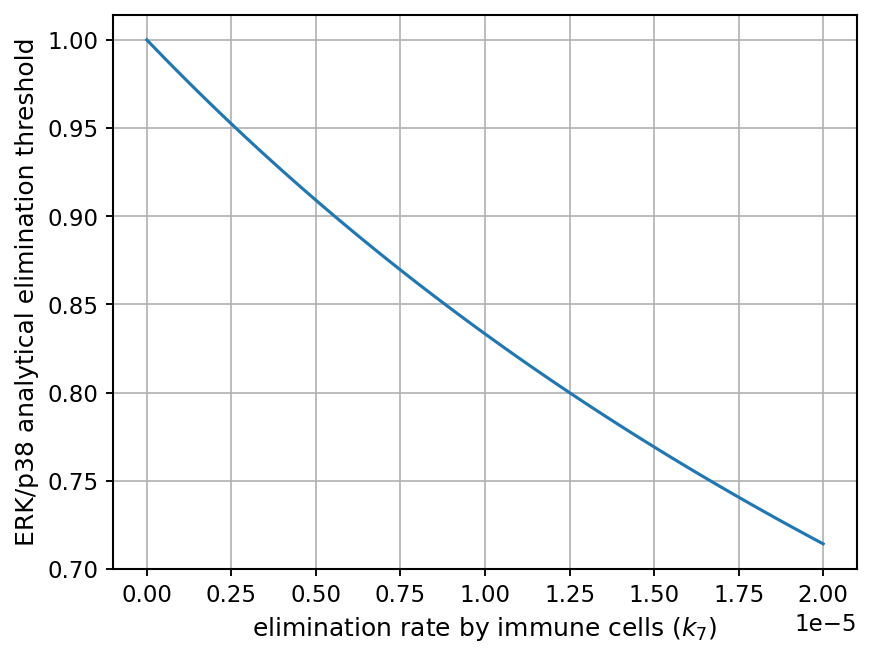

In [559]:
plt.plot(k8_v, k8_tres)
plt.grid()
plt.ylabel(r'ERK/p38 analytical elimination threshold', fontsize = 12)
plt.xlabel(r'elimination rate by immune cells ($k_{7}$)', fontsize = 12)
plt.savefig('x_elim.png')
plt.show()

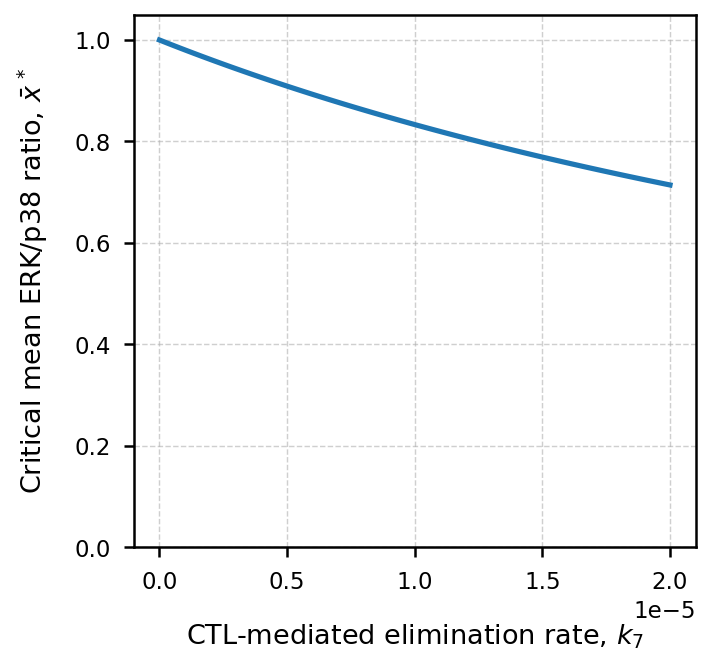

In [57]:
import matplotlib.pyplot as plt
import numpy as np

k8_v = np.asarray(k8_v)
k8_tres = np.asarray(k8_tres)

fig, ax = plt.subplots(figsize=(4.8, 4.8))

ax.plot(k8_v, k8_tres, linewidth=2.5)

ax.set_xlabel(
    r'CTL-mediated elimination rate, $k_7$',
    fontsize=13,
    labelpad=14
)

ax.set_ylabel(
    r'Critical mean ERK/p38 ratio, $\bar{x}^{\,*}$',
    fontsize=13,
    labelpad=12
)

ax.set_ylim(0, 1.05)

ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.6)

ax.tick_params(
    axis='both',
    which='major',
    labelsize=11,
    width=1.2,
    length=5,
    pad=6
)

for spine in ax.spines.values():
    spine.set_linewidth(1.2)

ax.ticklabel_format(axis='x', style='sci', scilimits=(-2, 2))

# Manually create more room at the bottom
fig.subplots_adjust(bottom=0.22, left=0.18, right=0.96, top=0.96)

plt.savefig('x_elim_publication.png', dpi=600)
plt.savefig('x_elim_publication.pdf')

plt.show()

In [41]:
k9_v = np.linspace(0, 0.05, 100)
k9_tres = np.zeros(100)

for i in range(100):
    k9_tres[i] = x_threshold(k10=1e-6, k7 = 1.5, k6=0.01, k9=k9_v[i], k8=1e-5)

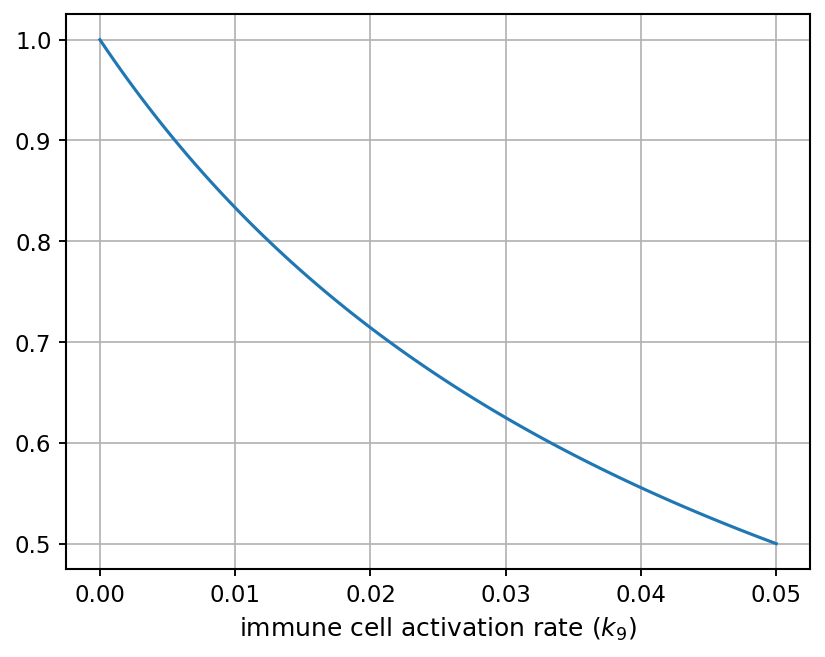

In [561]:
plt.plot(k9_v, k9_tres)
plt.grid()
#plt.ylabel(r'ERK/p38 analytical elimination threshold', fontsize = 12)
plt.xlabel(r'immune cell activation rate ($k_{9}$)', fontsize = 12)
plt.savefig('x_act.png')
plt.show()

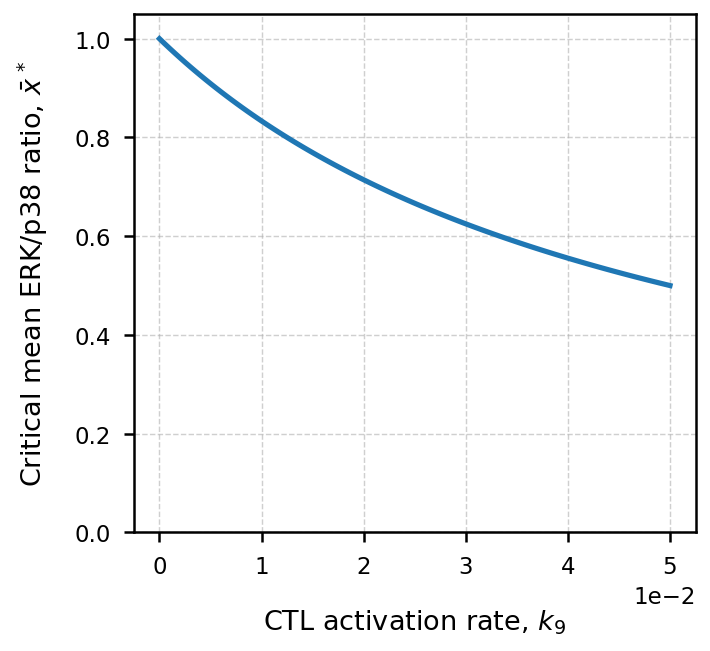

In [43]:
import matplotlib.pyplot as plt
import numpy as np

k9_v = np.asarray(k9_v)
k9_tres = np.asarray(k9_tres)

fig, ax = plt.subplots(figsize=(4.8, 4.8))

ax.plot(k9_v, k9_tres, linewidth=2.5)

ax.set_xlabel(
    r'CTL activation rate, $k_9$',
    fontsize=13,
    labelpad=14
)

ax.set_ylabel(
    r'Critical mean ERK/p38 ratio, $\bar{x}^{\,*}$',
    fontsize=13,
    labelpad=12
)

ax.set_ylim(0, 1.05)

ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.6)

ax.tick_params(
    axis='both',
    which='major',
    labelsize=11,
    width=1.2,
    length=5,
    pad=6
)

for spine in ax.spines.values():
    spine.set_linewidth(1.2)

ax.ticklabel_format(axis='x', style='sci', scilimits=(-2, 2))

# Extra room for two-line xlabel
fig.subplots_adjust(bottom=0.24, left=0.18, right=0.96, top=0.96)

plt.savefig('x_act_publication.png', dpi=600)
plt.savefig('x_act_publication.pdf')

plt.show()

In [278]:
k4 = 0.01        # movement to profliferative state following EGF consumption
k5 = 0.1/1e7     # movement to quiescency due to exposure to immune cells
k6 = 0.5        #movement to quiescency due to stress
k8 = 1e-5    # elimination rate by immune cells
k10 = 1e-6      #rate of immunosuppression
k7 = 1.5         #division rate

eT, cT, iT, nT, c_p_T = simulation(k4, k5, k6, k8, k10, k7, 0)

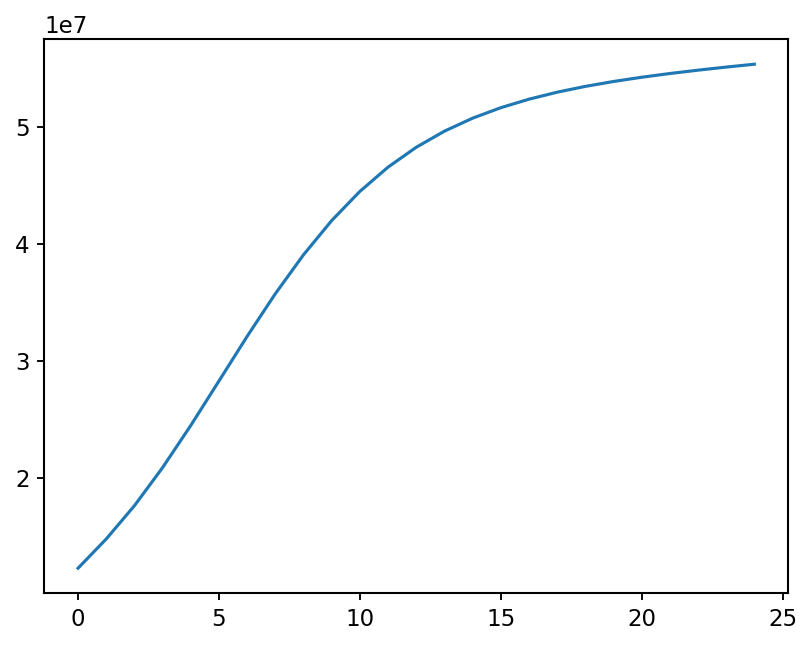

In [279]:
plt.plot(cT)

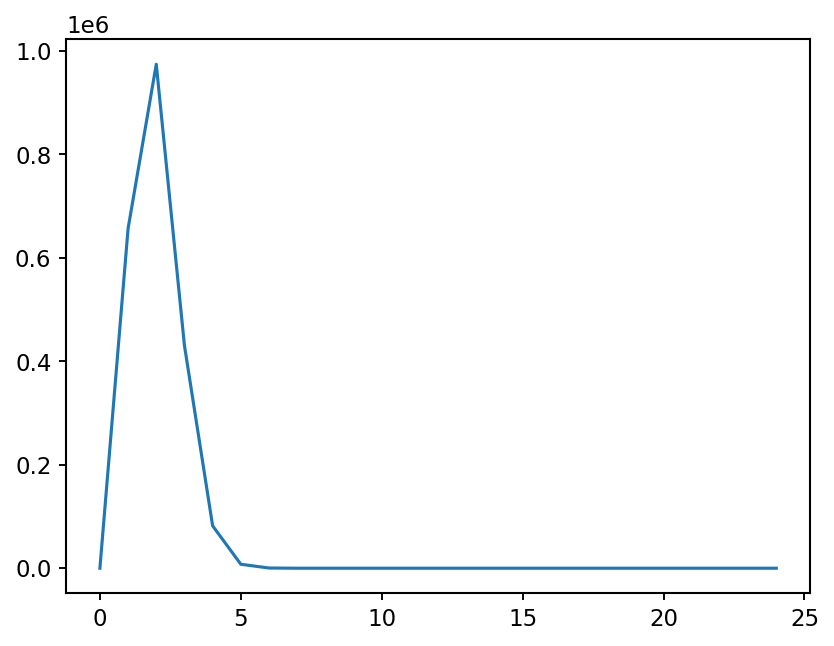

In [280]:
plt.plot(c_p_T[24])

In [46]:
#Nd = 25
#dt = 0.0001

def simulation2(k4, k5, k6, k8, k10, k7, ktreat):

    c = np.zeros([int(Nr/dx)])
    c_new = np.zeros([int(Nr/dx)])
    
    e = e0
    e_new = e0
    
    cT = np.zeros([int(Nd)])
    eT = np.zeros([int(Nd)])
    iT = np.zeros([int(Nd)])
    nT = np.zeros([int(Nd)])
    xT = np.zeros([int(Nd)])
    c_p_T = np.zeros([int(Nr/dx), int(Nd)])
    
    i = 4000
    i_new = 4000
    
    # Initial condition for c
    for ix in range(int(Nr/dx)):
        if int(0.4/dx) <= ix < int(0.6/dx):
            c[ix] = 70000000
    
    cT[0] = np.trapz(c, dx=dx)
    xT[0] = np.trapz(c*XX, dx=dx)/np.trapz(c, dx=dx)
    eT[0] = e
    iT[0] = i
    nT[0] = np.trapz(c, dx=dx)*2e-6
    c_p_T[:, 0] = c.copy()
    
    day = 1  # day counter for indexing into cT, eT, iT
    
    for t in range(1, int(Nd/dt)):
        e_new = e + dt*(k1*(e0-e) - k2*integrate_vector(XX*c, dx)*e - k3*e)
        i_new = i + dt*(k9*act(a0, a1, dx, XX, c)*(i0-i) - k10*act(b0, b1, dx, (1-XX), c)*i - k11*i)
    
        for ix in range(1, int(Nr/dx)-1):
            c_new[ix] = (c[ix] 
                         - (dt*k4*e*(Nr - XX[ix])*(c[ix] - c[ix-1])/dx + dt*k4*e*c[ix])
                         
                         + dt*k5*i*XX[ix]*(c[ix+1] - c[ix])/dx + dt*k5*i*c[ix]

                         - (dt*ktreat*(Nr - XX[ix])*(c[ix] - c[ix-1])/dx + dt*ktreat*c[ix])
                         
                         + dt*k6*XX[ix]*(1-e)*(c[ix+1] - c[ix])/dx + dt*k6*(1-e)*c[ix]
                         
                         + dt*k7*XX[ix]*c[ix]
                         - dt*k8*i*XX[ix]*c[ix]
                         - dt*k77*XX[ix]*c[ix])
    
        # Boundary conditions
        #c_new[0] = c[1]
        #c_new[-1] = c[-2]
    
        e = e_new
        i = i_new
        c = c_new.copy()
    
        if t % int(1/dt) == 0:
            eT[day] = e
            cT[day] = np.trapz(c, dx=dx)
            xT[day] = np.trapz(c*XX, dx=dx)/np.trapz(c, dx=dx)
            iT[day] = i
            nT[day] = np.trapz(c, dx=dx)*2e-6
            c_p_T[:, day] = c.copy()
            day += 1
            

    return eT, cT, iT, nT, c_p_T, xT

In [50]:
k4 = 0.3       # movement to profliferative state following EGF consumption
k5 = 10/1e7     # movement to quiescency due to exposure to immune cells
k6 = 0.01        #movement to quiescency due to stress
k8 = 1e-5    # elimination rate by immune cells
k10 = 1e-6      #rate of immunosuppression
k7 = 1.5         #division rate

eT, cT, iT, nT, c_p_T, xT = simulation2(k4, k5, k6, k8, k10, k7, 0)

In [51]:
print(cT[24])
print(xT[24])
print(iT[24])

83698.02171250847
0.9291635703308504
6350.547690108436


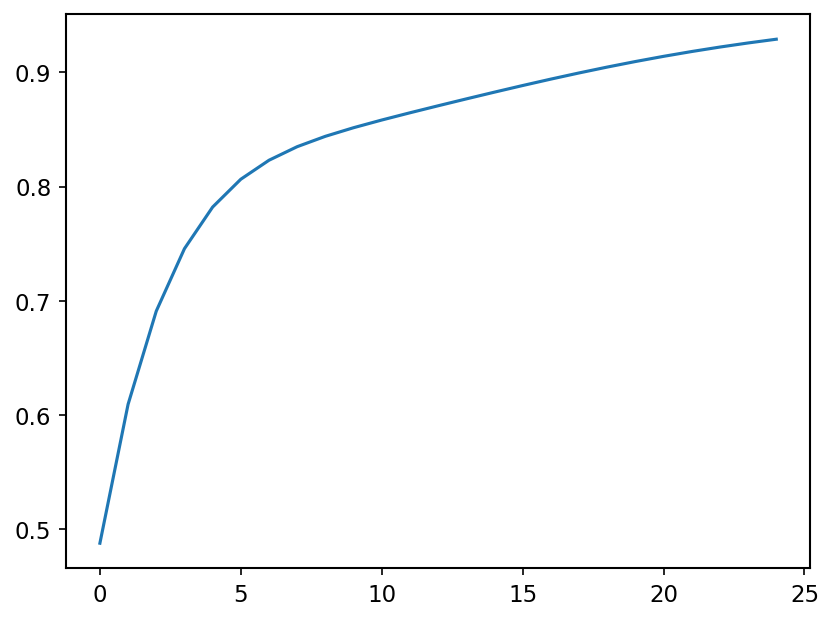

In [52]:
plt.plot(xT)

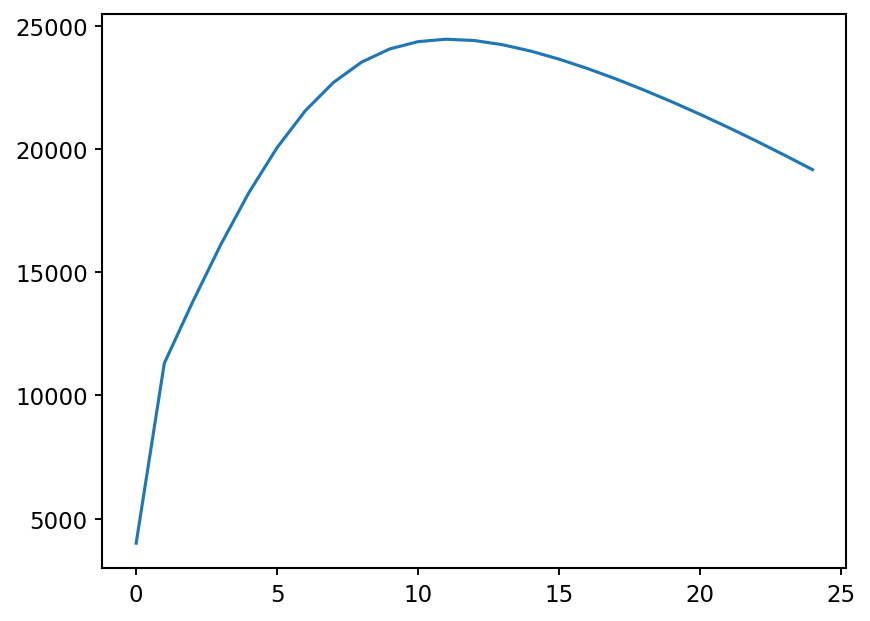

In [512]:
plt.plot(iT)

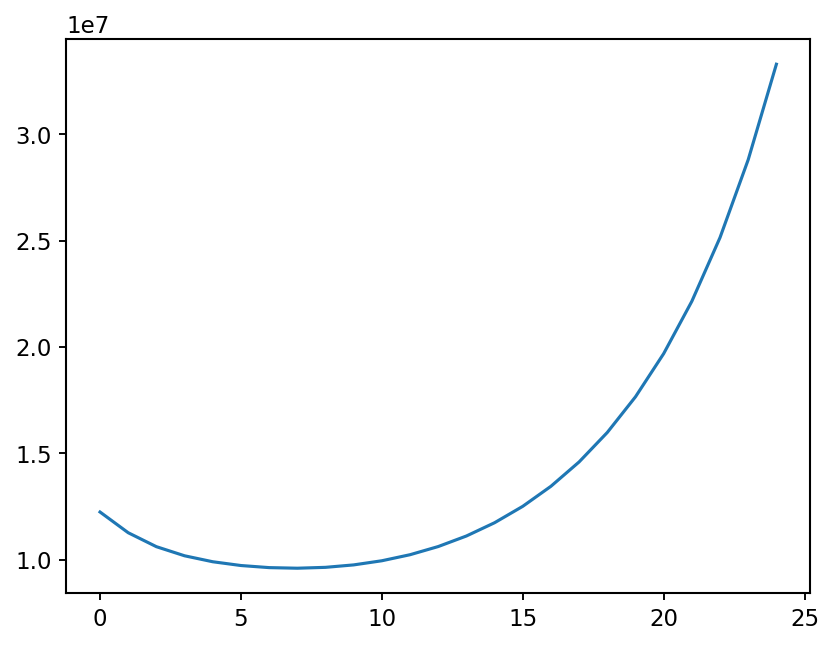

In [513]:
plt.plot(cT)

In [48]:
eT, cT1, iT1, nT, c_p_T, xT1 = simulation2(k4, k5, 0, k8, k10, k7, 0)
eT, cT2, iT2, nT, c_p_T, xT2 = simulation2(k4, k5, 0.01, k8, k10, k7, 0)
eT, cT3, iT3, nT, c_p_T, xT3 = simulation2(k4, k5, 0.2, k8, k10, k7, 0.)

C:\Users\Bouchnita\AppData\Local\Temp\ipykernel_54292\3271683010.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("RdYlGn")


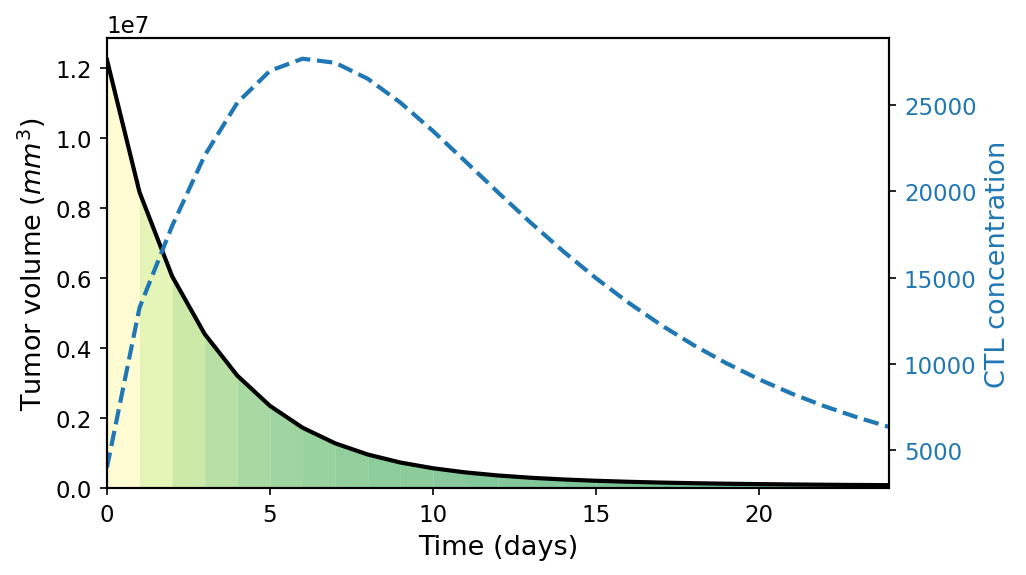

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

cT3 = np.asarray(cT)
xT3 = np.asarray(xT)
iT3 = np.asarray(iT)  # <-- CTL concentration array (rename if needed)
t = np.arange(len(cT3))

# Colormap: red (0) → green (1)
cmap = cm.get_cmap("RdYlGn")
norm = Normalize(vmin=0, vmax=1)

fig, ax = plt.subplots(figsize=(7, 4))

# ============================
# Main curve (tumor cells)
# ============================
ax.plot(t, cT3, color="black", linewidth=2, zorder=3, label="Tumor burden")

# Fill under curve with varying color
for i in range(len(cT3) - 1):
    ax.fill_between(
        t[i:i+2],
        0,
        cT3[i:i+2],
        color=cmap(norm(xT3[i])),
        alpha=0.6,
        linewidth=0
    )

# ============================
# Secondary axis: CTLs
# ============================
ax2 = ax.twinx()
ax2.plot(
    t,
    iT3,
    linestyle="--",
    color="tab:blue",
    linewidth=2,
    label="CTL concentration"
)

ax2.set_ylabel("CTL concentration", color="tab:blue")
ax2.tick_params(axis='y', labelcolor="tab:blue")

# ============================
# Colorbar
# ============================
#sm = cm.ScalarMappable(norm=norm, cmap=cmap)
#sm.set_array([])
#cbar = plt.colorbar(sm, ax=ax, pad=0.02)
#cbar.set_label(r"$x_{T3}$", rotation=90)

# ============================
# Labels & limits
# ============================
ax.set_xlabel("Time (days)")
ax.set_ylabel(r"Tumor volume ($mm^3$)")

ax.set_xlim(t[0], t[-1])
ax.set_ylim(0, 1.05 * np.max(cT3))

# ============================
# Legend on the right
# ============================
#lines1, labels1 = ax.get_legend_handles_labels()
#lines2, labels2 = ax2.get_legend_handles_labels()
"""
ax2.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    frameon=False
)
"""
plt.tight_layout()
#plt.savefig('elimination.png')
plt.show()


C:\Users\Bouchnita\AppData\Local\Temp\ipykernel_54292\1788672590.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("RdYlGn")


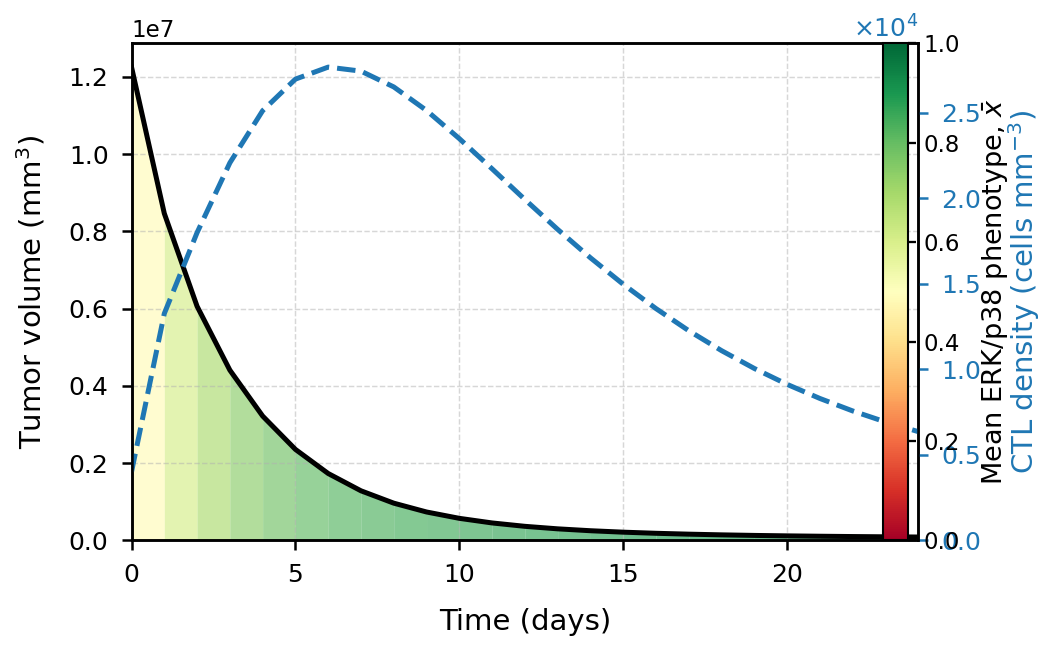

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.ticker import ScalarFormatter

cT3 = np.asarray(cT, dtype=float)
xT3 = np.asarray(xT, dtype=float)
iT3 = np.asarray(iT, dtype=float)

t = np.arange(len(cT3))

# Colormap: red (0) → green (1)
cmap = cm.get_cmap("RdYlGn")
norm = Normalize(vmin=0, vmax=1)

fig, ax = plt.subplots(figsize=(7, 4.5))

# Colored tumor area
for j in range(len(cT3) - 1):
    ax.fill_between(
        t[j:j+2],
        0,
        cT3[j:j+2],
        color=cmap(norm(xT3[j])),
        alpha=0.65,
        linewidth=0
    )

# Tumor curve
ax.plot(
    t,
    cT3,
    color="black",
    linewidth=2.4
)

# Secondary axis: CTLs
ax2 = ax.twinx()
ax2.plot(
    t,
    iT3,
    linestyle="--",
    color="tab:blue",
    linewidth=2.4
)

# Labels
ax.set_xlabel("Time (days)", fontsize=14, labelpad=10)
ax.set_ylabel(r"Tumor volume (mm$^3$)", fontsize=14, labelpad=10)
ax2.set_ylabel(r"CTL density (cells mm$^{-3}$)", fontsize=14, labelpad=12, color="tab:blue")

# Limits
ax.set_xlim(t[0], t[-1])
ax.set_ylim(0, 1.05 * np.max(cT3))
ax2.set_ylim(0, 1.05 * np.max(iT3))

# Ticks
ax.tick_params(axis="both", labelsize=12, width=1.2, length=5, pad=6)
ax2.tick_params(axis="y", labelsize=12, width=1.2, length=5, pad=6, colors="tab:blue")

# Force scientific notation as ×10^n instead of 1eN
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))
ax2.yaxis.set_major_formatter(formatter)

# Make the offset text readable and mathematical
ax2.yaxis.get_offset_text().set_fontsize(12)

# Grid and spines
ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.5)

for spine in ax.spines.values():
    spine.set_linewidth(1.2)

for spine in ax2.spines.values():
    spine.set_linewidth(1.2)

# Colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, pad=0.12, fraction=0.045)
cbar.set_label(r"Mean ERK/p38 phenotype, $\bar{x}$", fontsize=13, labelpad=10)
cbar.ax.tick_params(labelsize=11, width=1.1, length=4)

fig.tight_layout()

plt.savefig("elimination_publication.png", dpi=600, bbox_inches="tight")
plt.savefig("elimination_publication.pdf", bbox_inches="tight")

plt.show()

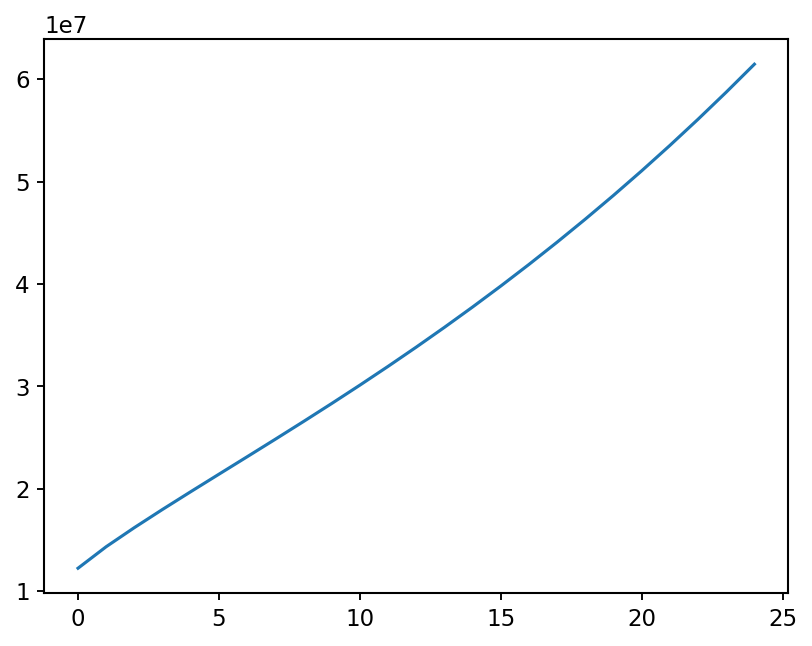

In [347]:
#plt.plot(cT1)
#plt.plot(cT2)
plt.plot(cT3)

In [381]:
eT, cT1, iT1, nT, c_p_T, xT1 = simulation2(k4, 10/1e7, 0.01, k8, k10, k7, 0.095)
#eT, cT2, iT2, nT, c_p_T, xT2 = simulation2(k4, 10/1e7, 0.1, k8, k10, k7, 0)
#eT, cT3, iT3, nT, c_p_T, xT3 = simulation2(k4, 500/1e7, 0.01, k8, k10, k7, 0)

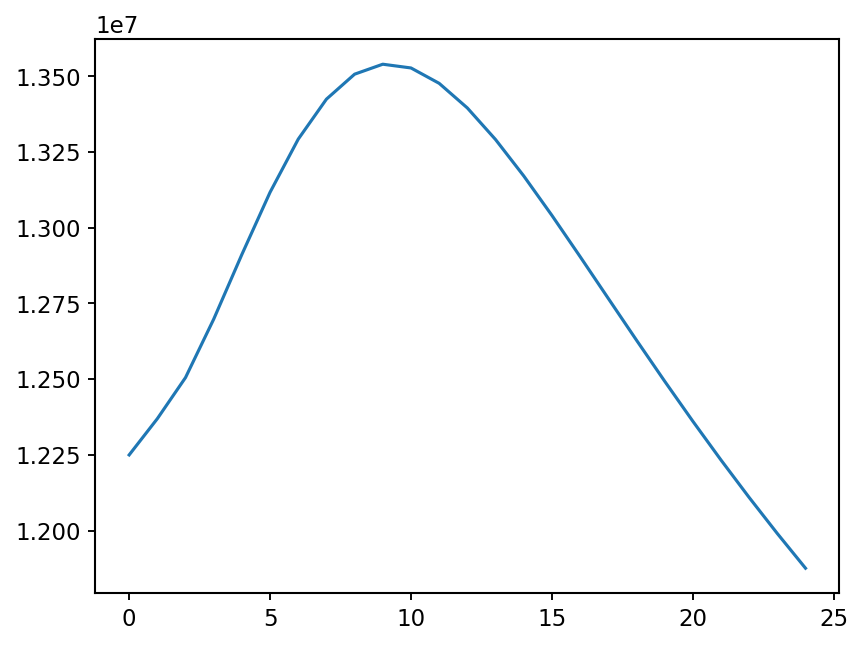

In [378]:
plt.plot(cT1)
#plt.plot(cT2)
#plt.plot(cT3)

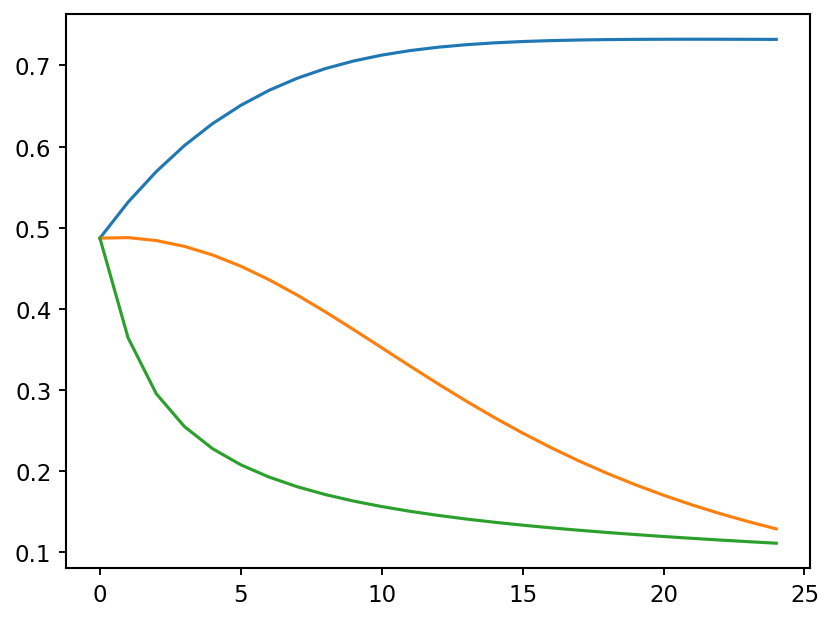

In [379]:
plt.plot(xT1)
plt.plot(xT2)
plt.plot(xT3)

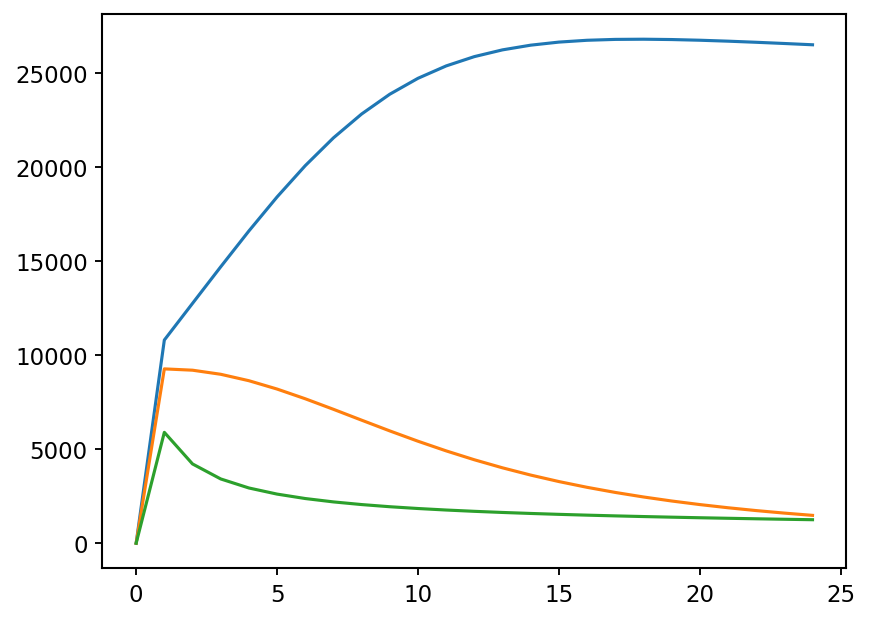

In [366]:
plt.plot(iT1)
plt.plot(iT2)
plt.plot(iT3)

C:\Users\Bouchnita\AppData\Local\Temp\ipykernel_45880\275351663.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("RdYlGn")


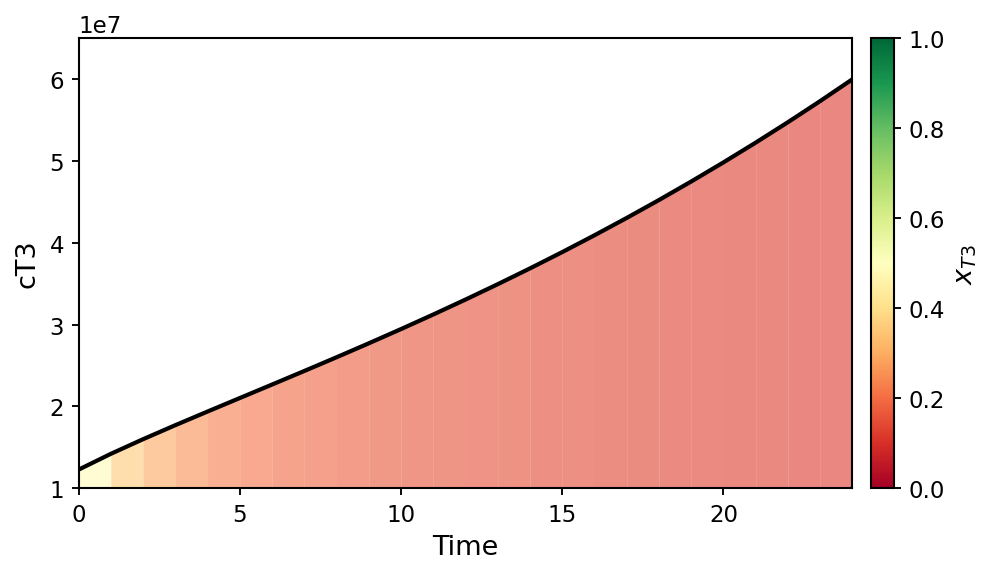

In [462]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

cT3 = np.asarray(cT)
xT3 = np.asarray(xT)
t = np.arange(len(cT3))   # or your actual time vector

# Colormap: red (0) → green (1)
cmap = cm.get_cmap("RdYlGn")
norm = Normalize(vmin=0, vmax=1)

fig, ax = plt.subplots(figsize=(7, 4))

# Plot main curve
ax.plot(t, cT3, color="black", linewidth=2, zorder=3)

# Fill under curve with varying color
for i in range(len(cT3) - 1):
    ax.fill_between(
        t[i:i+2],
        0,
        cT3[i:i+2],
        color=cmap(norm(xT3[i])),
        alpha=0.6,
        linewidth=0
    )

# Colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"$x_{T3}$", rotation=90)

ax.set_xlabel("Time")
ax.set_ylabel("cT3")

ax.set_xlim(t[0], t[-1])
ax.set_ylim(0, 1.05 * np.max(cT3))

plt.tight_layout()
plt.axis([0, 24, 1e7, 6.5e7])
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

cT3 = np.asarray(cT)
xT3 = np.asarray(xT)
iT3 = np.asarray(iT)  # <-- CTL concentration array (rename if needed)
t = np.arange(len(cT3))

# Colormap: red (0) → green (1)
cmap = cm.get_cmap("RdYlGn")
norm = Normalize(vmin=0, vmax=1)

fig, ax = plt.subplots(figsize=(7, 4))

# ============================
# Main curve (tumor cells)
# ============================
ax.plot(t, cT3, color="black", linewidth=2, zorder=3, label="Tumor burden")

# Fill under curve with varying color
for i in range(len(cT3) - 1):
    ax.fill_between(
        t[i:i+2],
        0,
        cT3[i:i+2],
        color=cmap(norm(xT3[i])),
        alpha=0.6,
        linewidth=0
    )

# ============================
# Secondary axis: CTLs
# ============================
ax2 = ax.twinx()
ax2.plot(
    t,
    iT3,
    linestyle="--",
    color="tab:blue",
    linewidth=2,
    label="CTL concentration"
)

ax2.set_ylabel("CTL concentration", color="tab:blue")
ax2.tick_params(axis='y', labelcolor="tab:blue")

# ============================
# Colorbar
# ============================
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"$x_{T3}$", rotation=90)

# ============================
# Labels & limits
# ============================
ax.set_xlabel("Time")
ax.set_ylabel("Tumor burden")

ax.set_xlim(t[0], t[-1])
ax.set_ylim(0, 1.05 * np.max(cT3))

# ============================
# Legend on the right
# ============================
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax2.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()


C:\Users\Bouchnita\AppData\Local\Temp\ipykernel_45880\4235663535.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("RdYlGn")


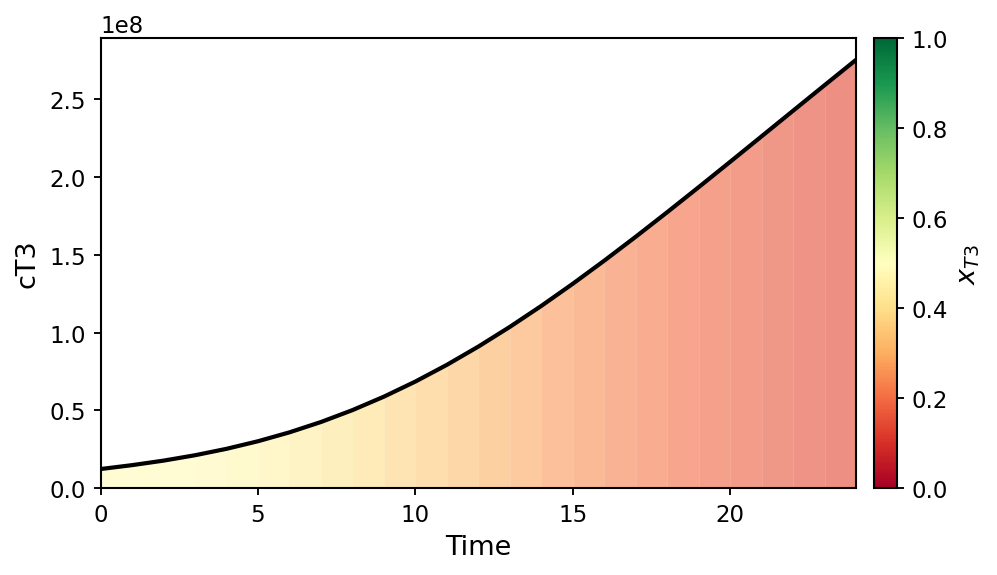

In [356]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

cT3 = np.asarray(cT2)
xT3 = np.asarray(xT2)
t = np.arange(len(cT2))   # or your actual time vector

# Colormap: red (0) → green (1)
cmap = cm.get_cmap("RdYlGn")
norm = Normalize(vmin=0, vmax=1)

fig, ax = plt.subplots(figsize=(7, 4))

# Plot main curve
ax.plot(t, cT3, color="black", linewidth=2, zorder=3)

# Fill under curve with varying color
for i in range(len(cT3) - 1):
    ax.fill_between(
        t[i:i+2],
        0,
        cT3[i:i+2],
        color=cmap(norm(xT3[i])),
        alpha=0.6,
        linewidth=0
    )

# Colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"$x_{T3}$", rotation=90)

ax.set_xlabel("Time")
ax.set_ylabel("cT3")

ax.set_xlim(t[0], t[-1])
ax.set_ylim(0, 1.05 * np.max(cT3))

plt.tight_layout()
plt.show()


C:\Users\Bouchnita\AppData\Local\Temp\ipykernel_45880\703106923.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("RdYlGn")


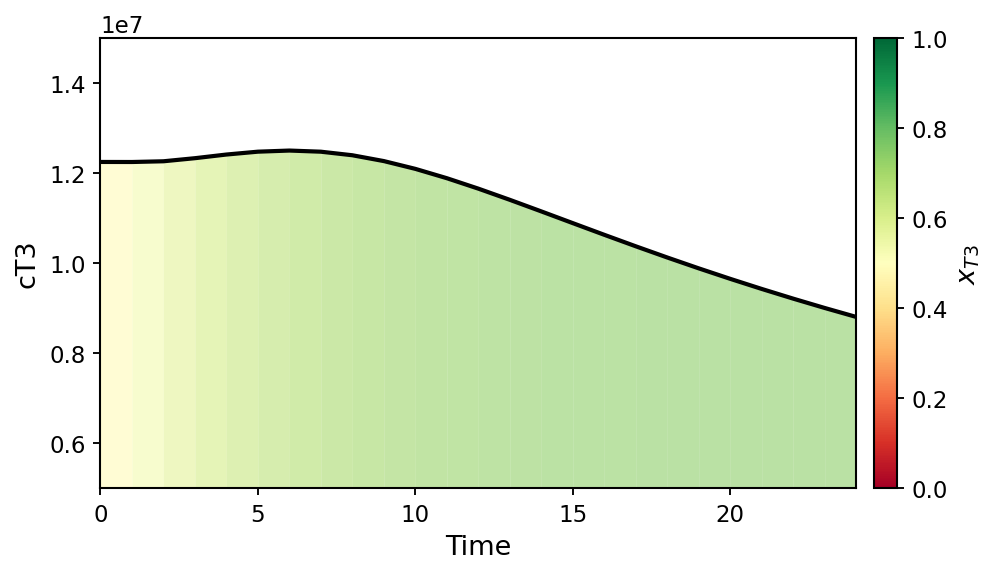

In [388]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

cT3 = np.asarray(cT1)
xT3 = np.asarray(xT1)
t = np.arange(len(cT1))   # or your actual time vector

# Colormap: red (0) → green (1)
cmap = cm.get_cmap("RdYlGn")
norm = Normalize(vmin=0, vmax=1)

fig, ax = plt.subplots(figsize=(7, 4))

# Plot main curve
ax.plot(t, cT3, color="black", linewidth=2, zorder=3)

# Fill under curve with varying color
for i in range(len(cT3) - 1):
    ax.fill_between(
        t[i:i+2],
        0,
        cT3[i:i+2],
        color=cmap(norm(xT3[i])),
        alpha=0.6,
        linewidth=0
    )

# Colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"$x_{T3}$", rotation=90)

ax.set_xlabel("Time")
ax.set_ylabel("cT3")

ax.set_xlim(t[0], t[-1])
ax.set_ylim(0, 1.05 * np.max(cT3))

plt.tight_layout()
plt.axis([0, 24, 0.5e7, 1.5e7])
plt.show()
